In [ ]:
# Importing all the required libraries for data manipulation, visualization, and machine learning
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

# Importing and splitting the data into training and testing

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("tea340yashjoshi/sepsis-prediction-dataset")

# print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sepsis-prediction-dataset


In [ ]:
# Mounting Google Drive to access files stored in your Google Drive account
from google.colab import drive
drive.mount('/content/drive')

# Reading the dataset from your specific Google Drive folder into a pandas DataFrame
combined = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset.csv')

In [ ]:
# combined = pd.read_csv('/kaggle/input/sepsis-prediction-dataset/Dataset.csv')

In [ ]:
# importing the file with the combined data of both the hospitals and splitting it into 2 parts

#  = pd.read_csv('/kaggle/input/prediction-of-sepsis/Dataset.csv')
#sepsis-physionet

# rows_to_drop = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) == 6)]
# df_train = combined.drop(rows_to_drop.index)

# Saving the training dataset to a local CSV file in the Colab environment
# df_train.to_csv('data_part1.csv', index=False)

# rows_to_drop = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) != 6)]
# df_test = combined.drop(rows_to_drop.index)

# Saving the testing dataset to a local CSV file
# df_test.to_csv('data_part2.csv', index=False)

In [ ]:
# importing the file with the combined data of both the hospitals and splitting it into 2 parts

# Identifying rows where Patient_ID length is exactly 6 characters (representing one specific hospital)

# Pisahkan pasien dengan ID selain 6 karakter menjadi Data Train (Rumah Sakit 1)
rows_to_drop_train = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) == 6)]

# Creating the training dataset by dropping the previously identified rows
df_train = combined.drop(rows_to_drop_train.index)

# Identifying rows where Patient_ID length is NOT 6 characters (representing the other hospital)
# Pisahkan pasien dengan ID tepat 6 karakter menjadi Data Test (Rumah Sakit 2)
rows_to_drop_test = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) != 6)]

# Creating the testing dataset by dropping these rows
df_test = combined.drop(rows_to_drop_test.index)

# Baris .to_csv dihapus agar komputasi di Colab lebih cepat karena hanya butuh dataframe-nya aja

In [ ]:
# Importing the training and testing data back from the local storage
# (Path adjusted for Google Colab compatibility)
df_train = pd.read_csv('/kaggle/working/data_part1.csv')
df_test = pd.read_csv('/kaggle/working/data_part2.csv')


In [ ]:
# importing the test and training data

df_train = pd.read_csv('data_part1.csv')
df_test = pd.read_csv('data_part2.csv')

# Exploratory data analysis

In [ ]:
# Displaying the first 15 rows of the training dataframe to inspect the data
df_train.head(15)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,1.0,0.0,17072.0
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,2.0,0.0,17072.0
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,3.0,0.0,17072.0
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,4.0,0.0,17072.0
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0.0,NaN,NaN,-0.02,5.0,0.0,17072.0
5,5,5,62.0,100.0,NaN,124.0,85.0,61.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,6.0,0.0,17072.0
6,6,6,61.0,100.0,NaN,101.0,75.0,58.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,7.0,0.0,17072.0
7,7,7,68.0,100.0,35.78,142.0,93.5,78.0,16.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,8.0,0.0,17072.0
8,8,8,71.0,100.0,NaN,121.0,74.0,91.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,9.0,0.0,17072.0
9,9,9,69.0,100.0,NaN,120.0,79.0,98.0,14.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,10.0,0.0,17072.0


As can be seen, this is a time series data. The dataframe has 44 columns. After the first loook at data, it can be observed that the data seems quite sparse.

In [ ]:
# let's list down all the different columns
# Listing all the column names present in the training dataframe

df_train.columns

Index(['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP',
       'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
       'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='object')

In [ ]:
# list of all the unique patients
# total number of patients present in the dataset
# Extracting a list of all unique Patient IDs from the testing dataset
patients = list(df_test['Patient_ID'].unique())
# Counting the total number of unique patients
len(patients)

6236

In [ ]:
# Function to draw correlation heat map
# Defining a function to plot a correlation heatmap
def corr_matrix(df):
  corr = df.corr() # Calculating the correlation matrix for the dataframe
  mask = np.triu(np.ones_like(corr, dtype=bool)) # Creating a mask to hide the upper triangle of the heatmap for better readability
  f, ax = plt.subplots(figsize=(40,40)) # Setting up the matplotlib figure size
  cmap = sns.diverging_palette(220, 10, as_cmap=True) # Choosing a diverging color palette for the heatmap
  sns.heatmap(corr, mask=mask, cmap="Paired", vmax=.3, center=0, # Drawing the heatmap with the mask and correct aspect ratio
              square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [ ]:
# Percentage of null values present in all the parameters

null_values = df_train.isnull().mean()*100 # Calculating the percentage of missing (null) values for each column in the training set
null_values = null_values.sort_values(ascending=False) # Sorting the missing value percentages in descending order
null_values # Displaying the null values series

EtCO2               100.000000
TroponinI            99.861334
Bilirubin_direct     99.844865
Fibrinogen           99.184143
Bilirubin_total      98.729937
Alkalinephos         98.483566
AST                  98.442065
Lactate              96.596916
SaO2                 95.161179
PTT                  95.110785
Calcium              94.971789
Phosphate            94.902950
Platelets            93.446791
Creatinine           93.330193
WBC                  92.473494
Magnesium            92.214936
HCO3                 91.921794
BUN                  91.825617
Chloride             91.670482
PaCO2                91.370752
Hgb                  91.203101
BaseExcess           89.753201
Potassium            89.236085
pH                   88.725886
Hct                  88.321086
Glucose              87.907064
FiO2                 85.982207
Temp                 66.399325
Unit1                49.760381
Unit2                49.760381
DBP                  48.036442
SBP                  14.777327
O2Sat   


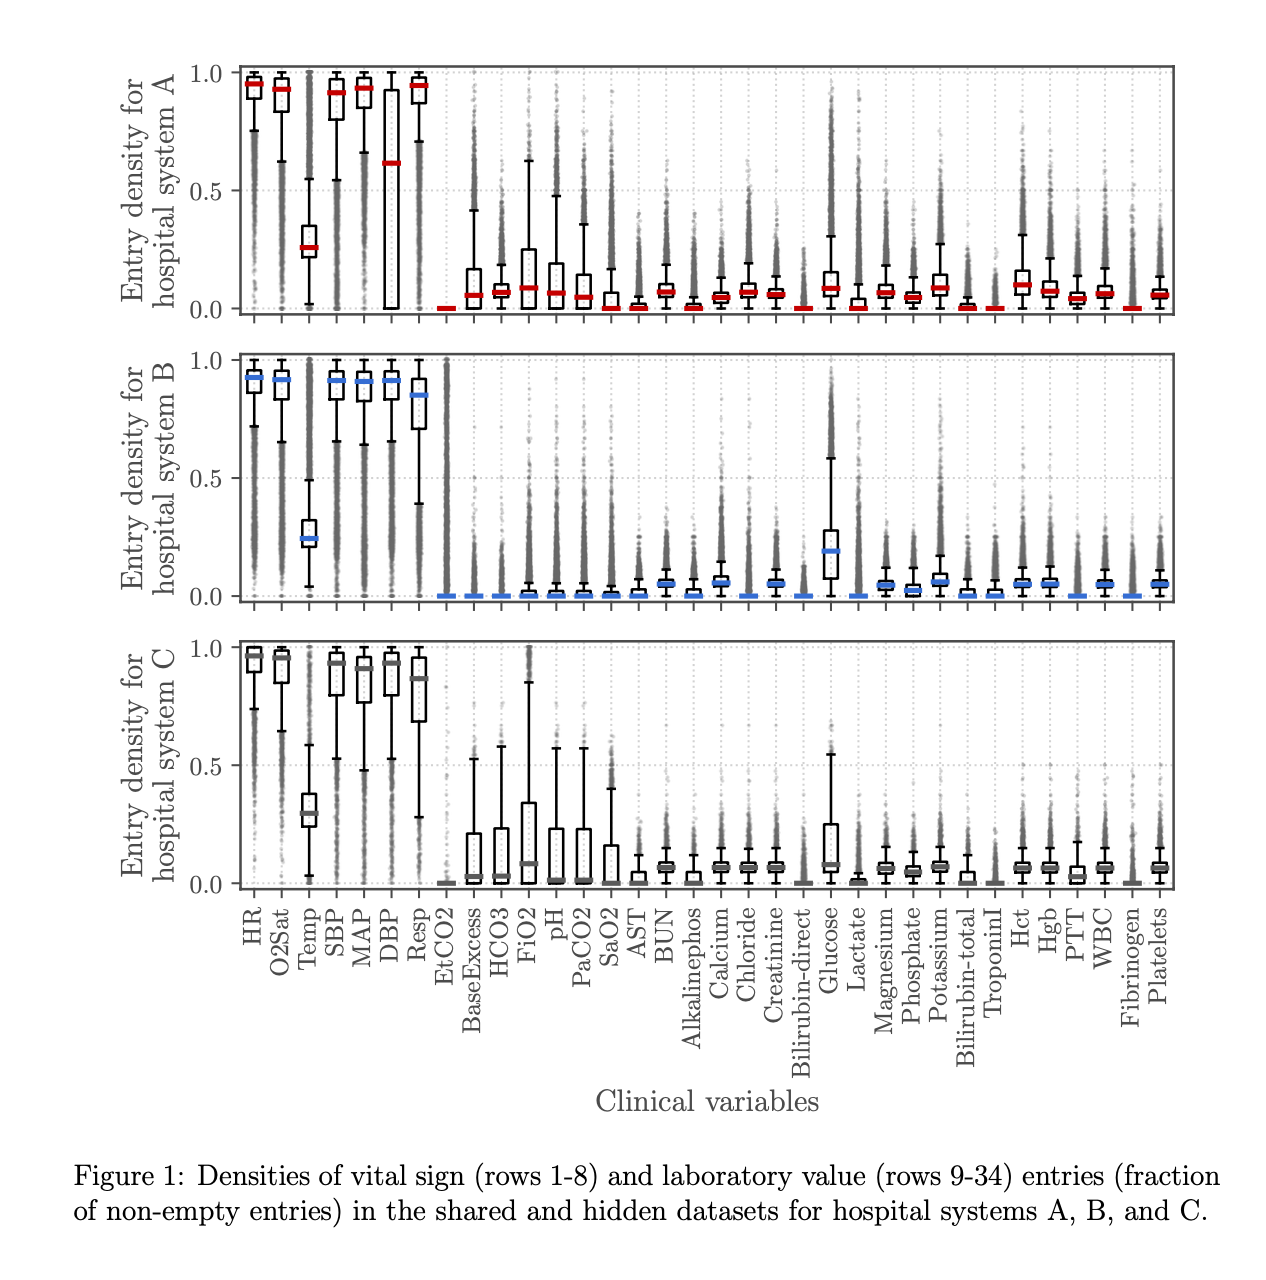

Image obtained from the official pdf of the PhysioNet Challenge. The image gives an overall idea of the number of records available for each feature, for all the three datasets of three different hospitals.

After thorough analysis of the data, it was found that a lot of the features were redundant, i.e. a lot of the features were indicative of the same parameter, so those features were removed on the basis of their sparsity. Another criteria taken into consideration was ease of getting the parameter among different hospitals, becuase some of the parameters are easier to obtain for a given hospital while some are expensive and for some a hospital does not even have infrastructure to get those features.

In [ ]:
# the features have been removed based on the number of null values and redundancy

# 'Unnamed: 0'-- this is the index column
# 'SBP' -- MAP is considered instead of SBP and DBP
# 'DBP' -- MAP is considered instead of SBP and DBP
# 'EtCO2' -- It is not readily. available and also not available in the dataset
# 'BaseExcess' -- It is an indicator of the health of kidney and pancreas but is redundant here becuase a lot of different features for kidney are being considered here.
# 'HCO3' -- It is also an indicator of the health of kidney and pancreas but is redundant here becuase a lot of different features for kidney are being considered here.
# 'pH' -- It is also an indicator of the health of kidney and pancreas but is redundant here becuase a lot of different features for kidney are being considered here.
# 'PaCO2' -- It is an indicator of respiratory health of an individual, we are considering SaO2 and FiO2 which are more readily avaiilable
# 'Alkalinephos' -- It is an indicator of the health of the liver of an individual, but we are considering Bilirubin instead of this, as data of this is more scarce.
# 'Calcium' -- It is also an indicator of the health of kidney but is redundant here becuase a lot of different features for kidney are being considered here.
# 'Magnesium' -- It is an indicator of metabolism and kidney health, but we are considering Lactate instead as it is more readily available
# 'Phosphate' -- It is also an indicator of the health of kidney but is redundant here becuase a lot of different features for kidney are being considered here.
# 'Potassium' -- It is also an indicator of the health of kidney but is redundant here becuase a lot of different features for kidney are being considered here.
# 'PTT' -- It is used to check inflammation. We are using WBC counts instead as it is easy to obtain.
# 'Fibrinogen' -- It is used to check blood clotting ability. We are using Platelets instead, as it is easier to obtain.
# 'Unit1' -- Both the columns Unit1 and Unit2 have been merged to form a single column.
# 'Unit2' -- Both the columns Unit1 and Unit2 have been merged to form a single column.

# Defining a set of columns to be dropped based on high missing values or redundancy
columns_drop={'Unnamed: 0','SBP','DBP','EtCO2','BaseExcess', 'HCO3','pH','PaCO2','Alkalinephos', 'Calcium','Magnesium',
'Phosphate','Potassium','PTT','Fibrinogen','Unit1','Unit2'}
df_train = df_train.assign(Unit=df_train['Unit1'] + df_train['Unit2']) # Combining 'Unit1' and 'Unit2' into a single 'Unit' column to simplify ICU unit representation
df_train_mod = df_train.drop(columns=columns_drop) # Dropping the previously defined redundant/sparse columns
df_train_mod.columns # Displaying the remaining columns

Index(['Hour', 'HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'FiO2', 'SaO2', 'AST',
       'BUN', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose',
       'Lactate', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'WBC',
       'Platelets', 'Age', 'Gender', 'HospAdmTime', 'ICULOS', 'SepsisLabel',
       'Patient_ID', 'Unit'],
      dtype='object')

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


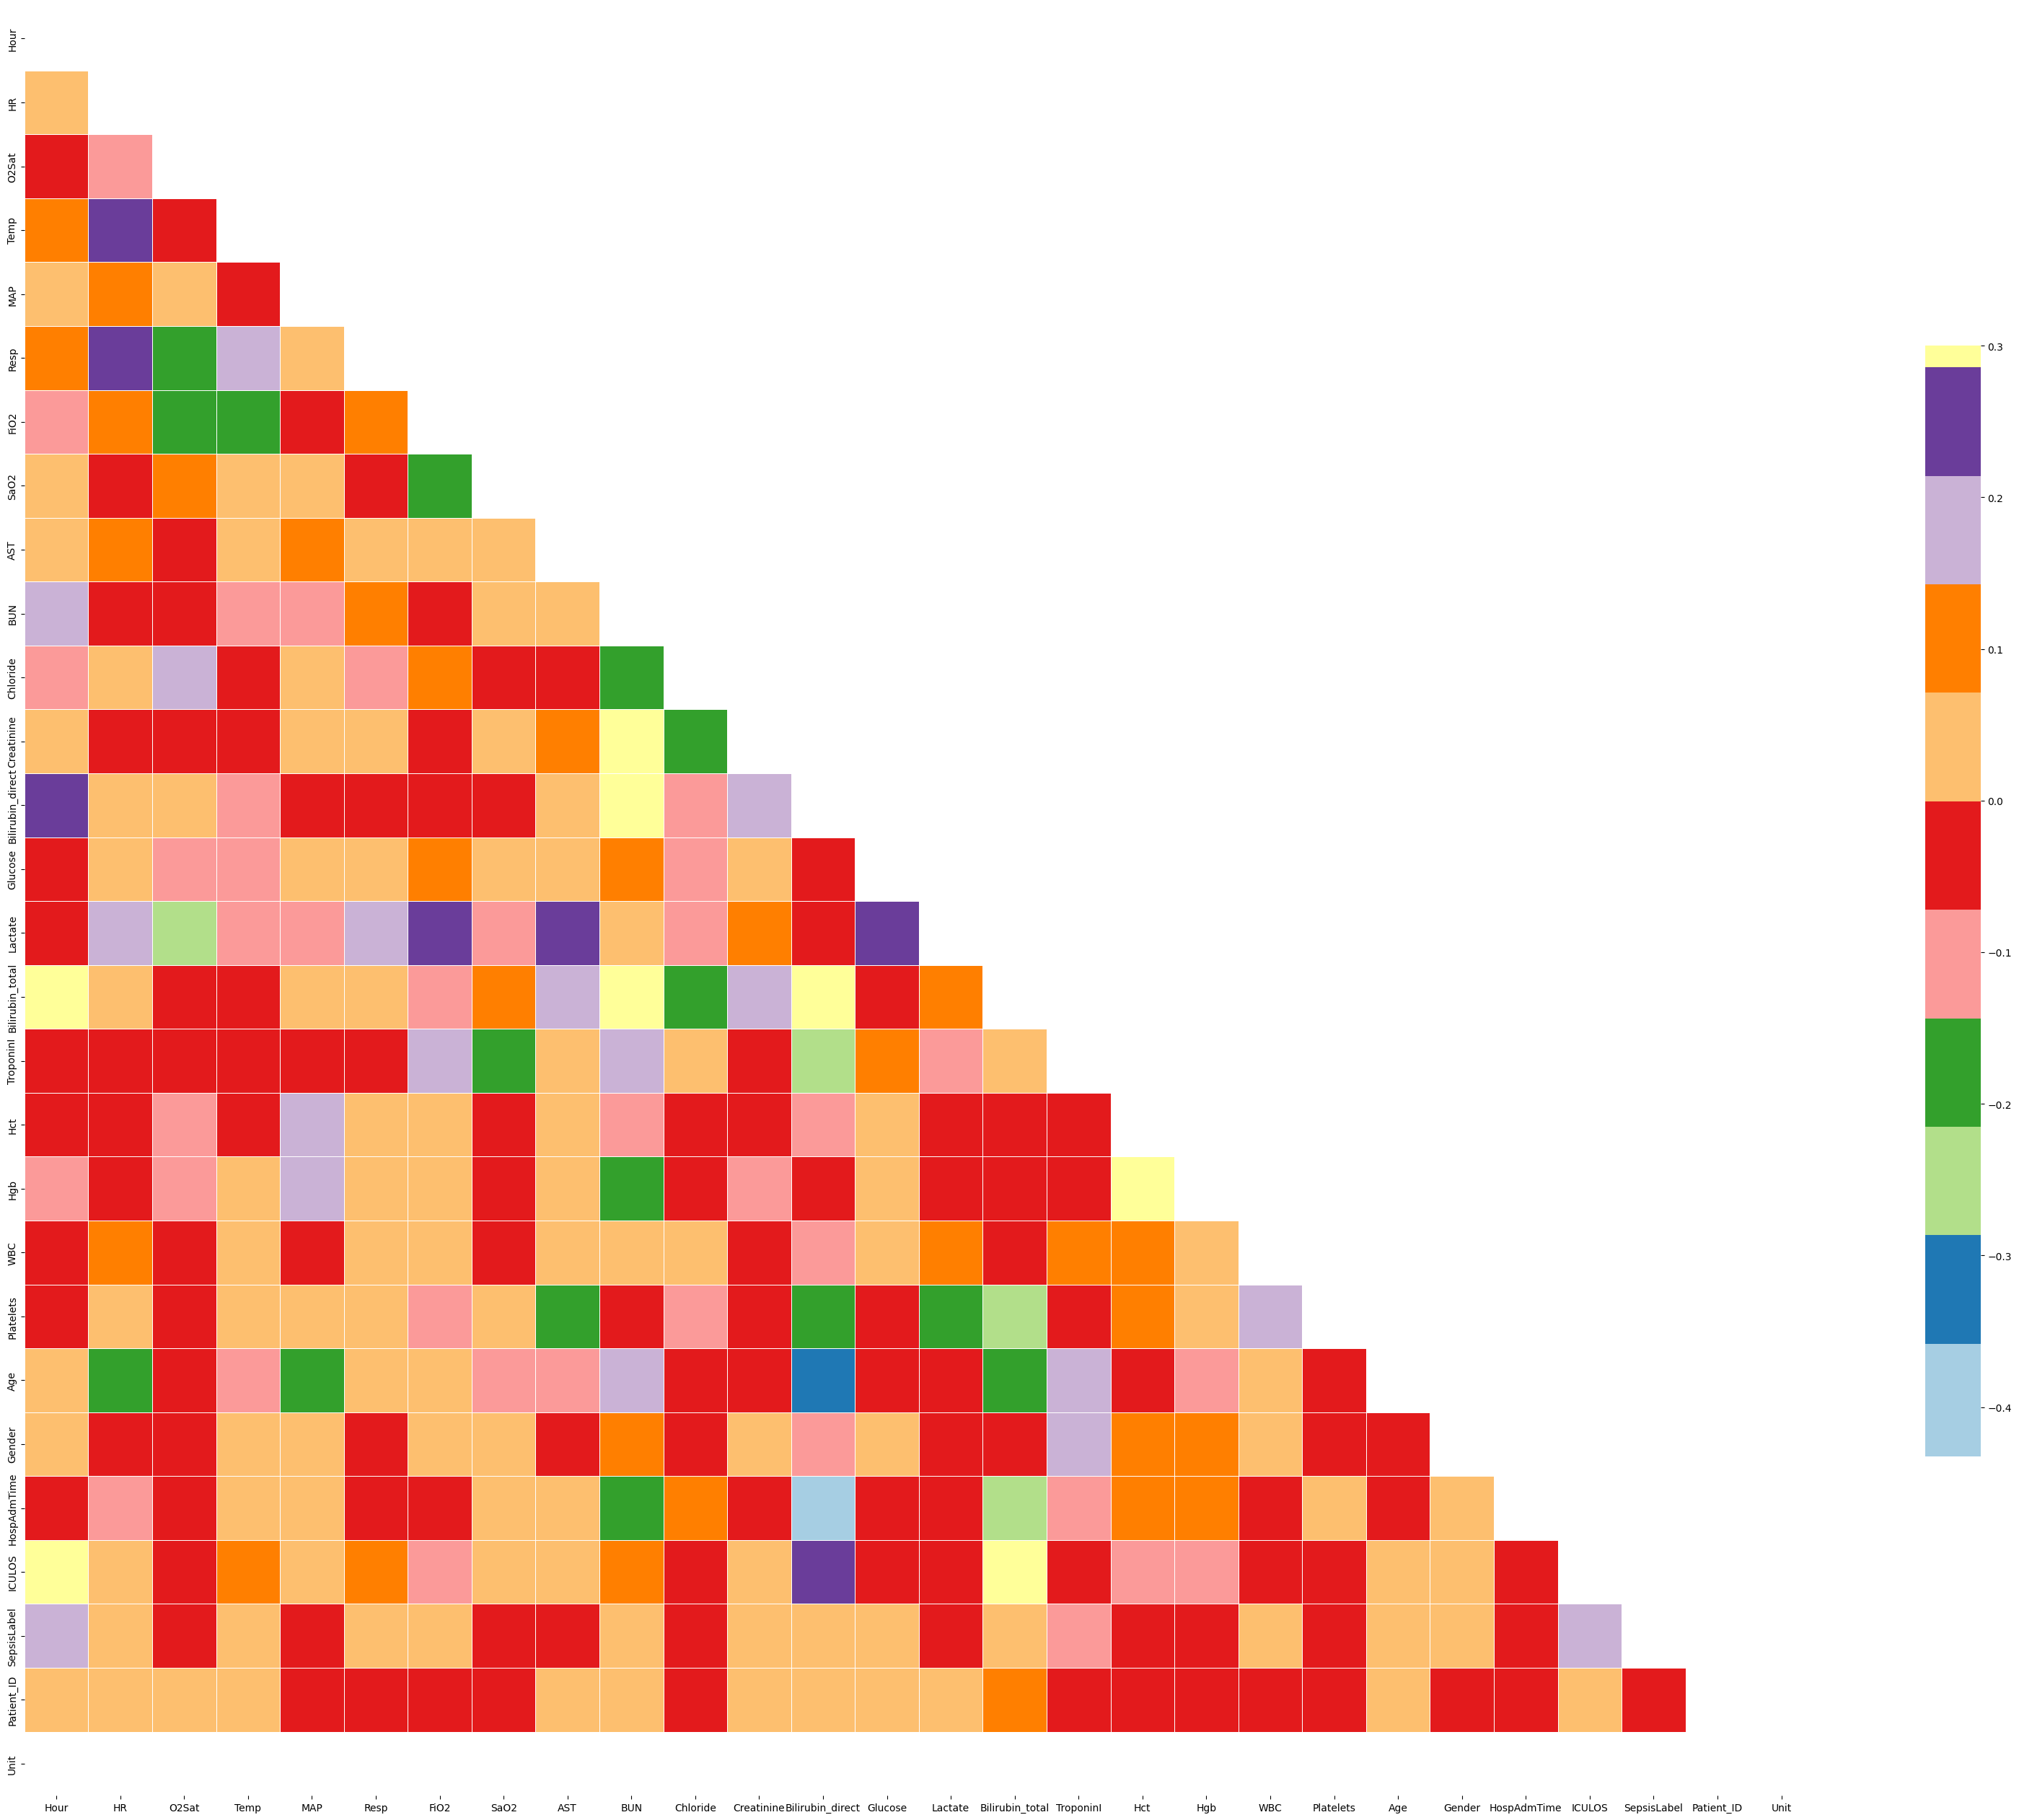

In [ ]:
# correlation matrix to check if there is high correlation between the remaining features

corr_matrix(df_train_mod)

As can be seen in this correlation heat map almost all of the feature do not have high correlation.

# Imputation

Since there are a lot of missing values in the dataset, therefore imputation was done to fill the missing values. While imputing, it is important to note that ***imputation should be done on per patient basis,*** otherwise the data from one patient will leak into the data of the other patient. Also another point that should be taken into consideration is that mean, median, mode can not directly be used to impute as it will result in uneven distribution of the parameters with respect to time.

In [ ]:
# Creating a copy of the modified dataframe for the imputation step
df_train_impute = df_train_mod.copy()
columns_impute = list(df_train_impute.columns) # Storing the column names of the new dataframe in a list

In [ ]:
# bfill and ffill for imputing
# Grouping the dataframe by 'Patient_ID' so imputation happens per patient (avoiding data leakage between patients)
grouped_by_patient = df_train_impute.groupby('Patient_ID')
df_train_impute = grouped_by_patient.apply(lambda x: x.bfill().ffill()) # Applying backward fill (bfill) then forward fill (ffill) to impute missing values sequentially for each patient

/tmp/ipykernel_12/468124072.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_impute = grouped_by_patient.apply(lambda x: x.bfill().ffill())


In [ ]:
df_train_impute.head() # Displaying the top 5 rows after imputation

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

Hour     HR  O2Sat   Temp    MAP  Resp  FiO2  SaO2   AST  \
Patient_ID                                                                   
1.0        72964     0   97.0   95.0  36.11  75.33  19.0  0.28  88.0  16.0   
           72965     1   97.0   95.0  36.11  75.33  19.0  0.28  88.0  16.0   
           72966     2   89.0   99.0  36.11  86.00  22.0  0.28  88.0  16.0   
           72967     3   90.0   95.0  36.11  91.33  30.0  0.28  88.0  16.0   
           72968     4  103.0   88.5  36.11  91.33  24.5  0.28  88.0  16.0   

                   BUN  ...   Hgb  WBC  Platelets    Age  Gender  HospAdmTime  \
Patient_ID              ...                                                     
1.0        72964  14.0  ...  12.5  5.7      317.0  83.14     0.0        -0.03   
           72965  14.0  ...  12.5  5.7      317.0  83.14     0.0        -0.03   
           72966  14.0  ...  12.5  5.7      317.0  83.14     0.0        -0.03   
           72967  14.0  ...  12.5  5.7      317.0  83.14     0.0        -0.03   
           72968  14.0  ...  12.5  5.7      317.0  83.14     0.0        -0.03   

                  ICULOS  SepsisLabel  Patient_ID  Unit  
Patient_ID                                               
1.0        72964     1.0          0.0         1.0   NaN  
           72965     2.0          0.0         1.0   NaN  
           72966     3.0          0.0         1.0   NaN  
           72967     4.0          0.0         1.0   NaN  
           72968     5.0          0.0         1.0   NaN  

[5 rows x 28 columns]

In [ ]:
# Now let's check the remaining proportion of missing values
# Recalculating the percentage of missing values after the first imputation round
null_values = df_train_impute.isnull().mean()*100
null_values = null_values.sort_values(ascending=False) # Sorting them in descending order
null_values # Displaying the updated missing values

TroponinI           97.088661
Bilirubin_direct    95.942109
Bilirubin_total     66.792158
AST                 66.173593
SaO2                57.892795
Lactate             56.383932
Unit                49.760216
FiO2                36.286503
WBC                  1.535213
Chloride             1.379749
Platelets            1.369538
Hgb                  1.192005
Creatinine           1.044446
BUN                  0.965067
Glucose              0.940693
Hct                  0.833317
Temp                 0.808943
Resp                 0.113634
O2Sat                0.027338
MAP                  0.007905
HR                   0.002964
Age                  0.000000
Gender               0.000000
HospAdmTime          0.000000
ICULOS               0.000000
SepsisLabel          0.000000
Patient_ID           0.000000
Hour                 0.000000
dtype: float64

'TroponinI', 'Bilirubin_direct', 'AST', 'Bilirubin_total', 'Lactate', 'SaO2', 'FiO2', 'Unit', 'Patient_ID'  have more than 25 percent of null values and hence are dropped from the dataset.

In [ ]:
# dropping all the columns with null values more than 25% and patient_id
# Defining a list of columns that still have more than 25% missing values, plus the Patient_ID
null_col = ['TroponinI', 'Bilirubin_direct', 'AST', 'Bilirubin_total', 'Lactate', 'SaO2', 'FiO2',
            'Unit', 'Patient_ID']
df_train_impute = df_train_impute.drop(columns=null_col) # Dropping these highly sparse columns from the imputed dataframe
df_train_impute.columns # Displaying the remaining columns

Index(['Hour', 'HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride',
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets', 'Age',
       'Gender', 'HospAdmTime', 'ICULOS', 'SepsisLabel'],
      dtype='object')

In [ ]:
# onehot encoding the gender
# Applying one-hot encoding to the 'Gender' column to convert categorical data into numerical format
one_hot = pd.get_dummies(df_train_impute['Gender'])
df_train_impute = df_train_impute.join(one_hot)# Joining the newly created one-hot encoded columns back to the dataframe
df_train_impute = df_train_impute.drop('Gender', axis=1) # Dropping the original 'Gender' column since it is now encoded


## Gaussian Transformation and Standard Normalization

Generally models tend to give a better result for a normal ditribution. So in the below cells we explored different techniques to plot histograms and QQ plots of all the features and then we applied different transformations on it to see which were giving good results. The ones giving the beest results were then adopted in the dataframe.

In [ ]:
# function to draw histogram and QQ plot
# Function to plot a histogram and a Q-Q plot to check if a variable follows a normal distribution
def diagnostic_plots(df, variable):
    fig = plt.figure(figsize=(15,4)) # Initializing the figure layout
    ax = fig.add_subplot(121) # Creating the first subplot for the histogram
    df[variable].hist(bins=30)
    ax = fig.add_subplot(122) # Creating the second subplot for the Q-Q plot
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.xlabel(variable) # Setting the x-axis label
    plt.show()# Rendering the plots

In [ ]:
# Function to test multiple mathematical transformations to make data distribution more Gaussian (normal)
def try_gaussian(df, col):
  print('actual plot')
  diagnostic_plots(df,col) # Plotting the original distribution
  # this applies yeojohnson plot
  df['col_yj'], param = stats.yeojohnson(df[col]) # Applying Yeo-Johnson transformation
  print('yeojohnson plot')
  diagnostic_plots(df, 'col_yj')
  # this applies exponential transformation
  df['col_1.5'] = df[col]**(1/1.5) # Applying fractional power transformation (x^(1/1.5))
  print('**1/1.5 plot')
  diagnostic_plots(df, 'col_1.5')
  df['col_.5'] = df[col]**(.5) # Applying square root transformation
  print('**.5 plot')
  # this applies inverse transformation
  diagnostic_plots(df, 'col_.5') # Applying reciprocal/inverse transformation (adding a tiny value to avoid division by zero)
  df['col_rec'] = 1 / (df[col]+0.00001)
  diagnostic_plots(df, 'col_rec')
  # this applies logarithmic trasnformation
  df['col_log'] = np.log(df[col]+1) # Applying logarithmic transformation (adding 1 to avoid log(0))
  diagnostic_plots(df, 'col_log')


/tmp/ipykernel_12/348954185.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_impute[col].fillna(df_train_impute[col].mean(), inplace=True)


O2Sat
actual plot


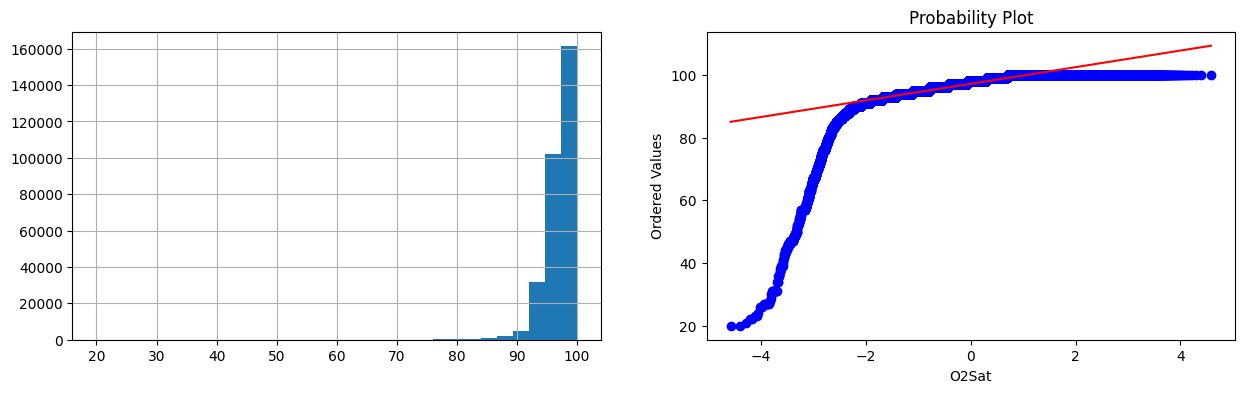

yeojohnson plot


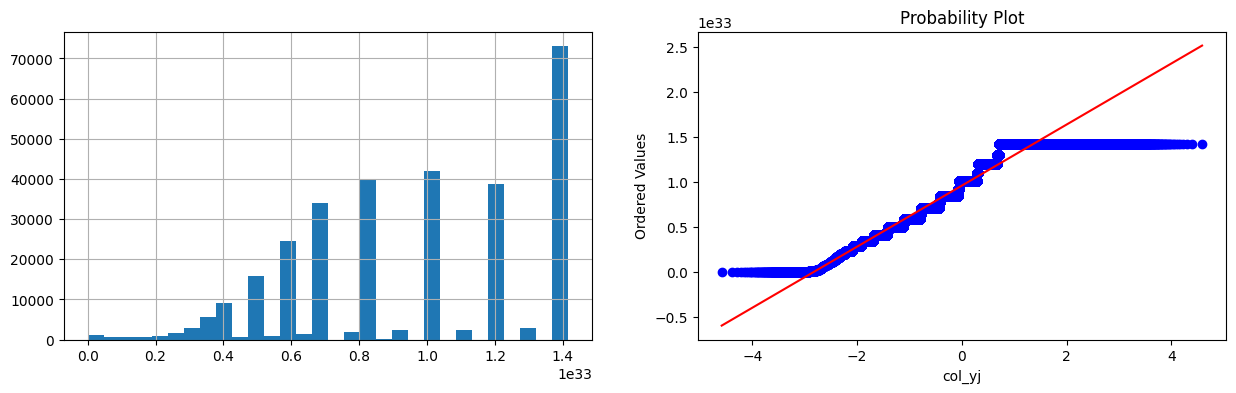

**1/1.5 plot


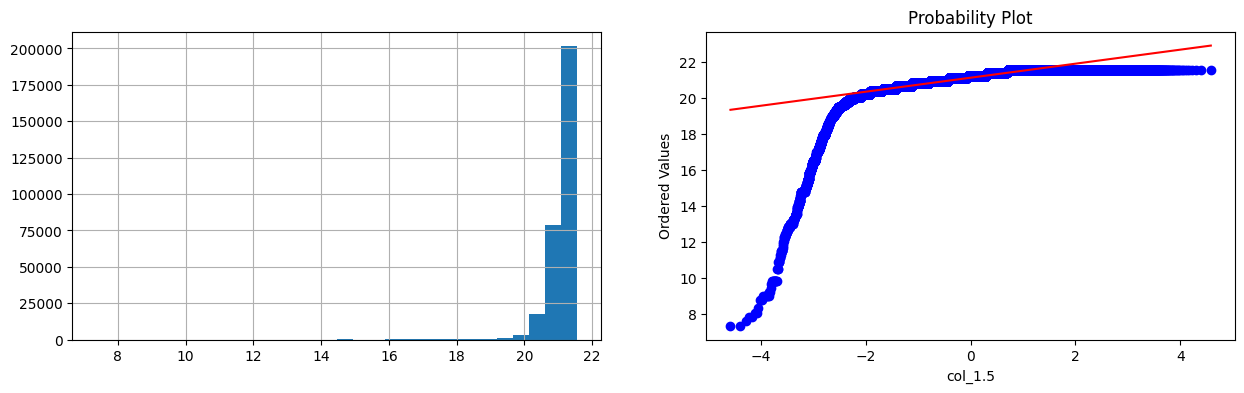

**.5 plot


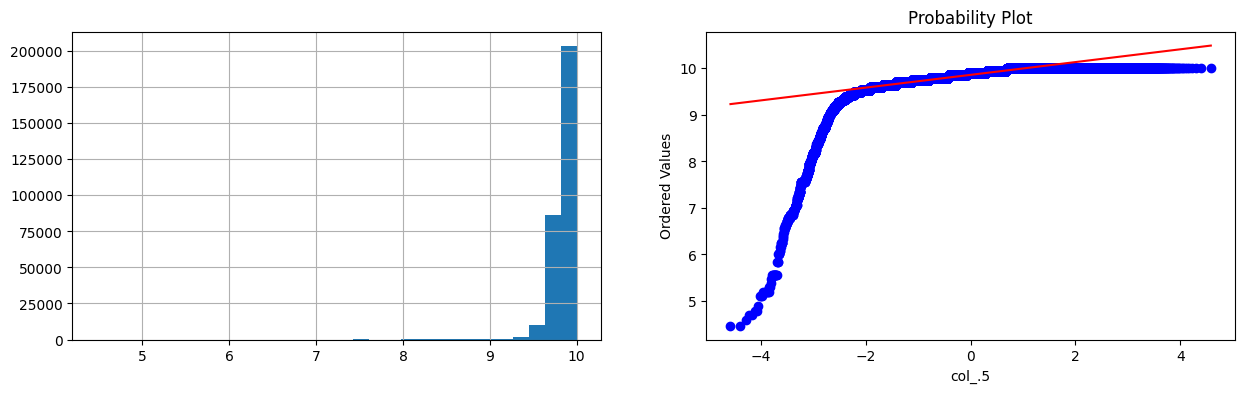

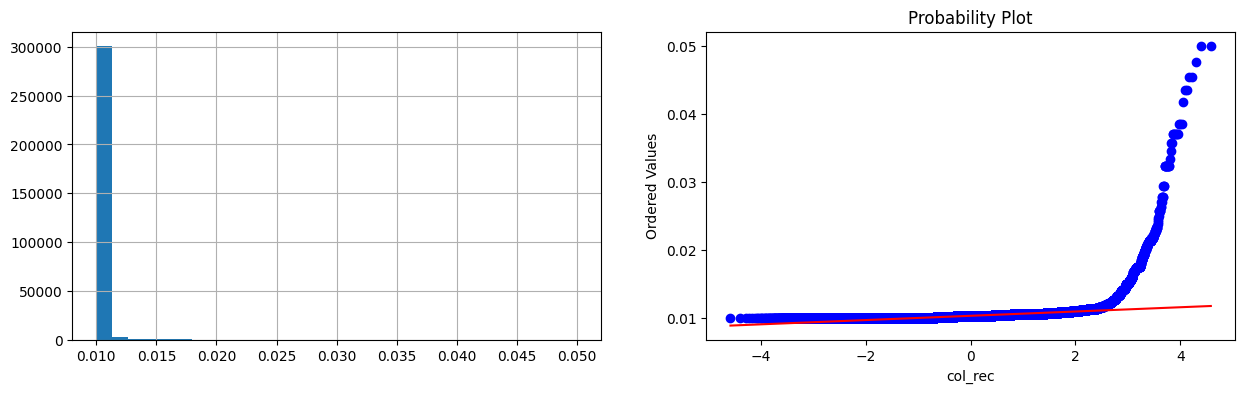

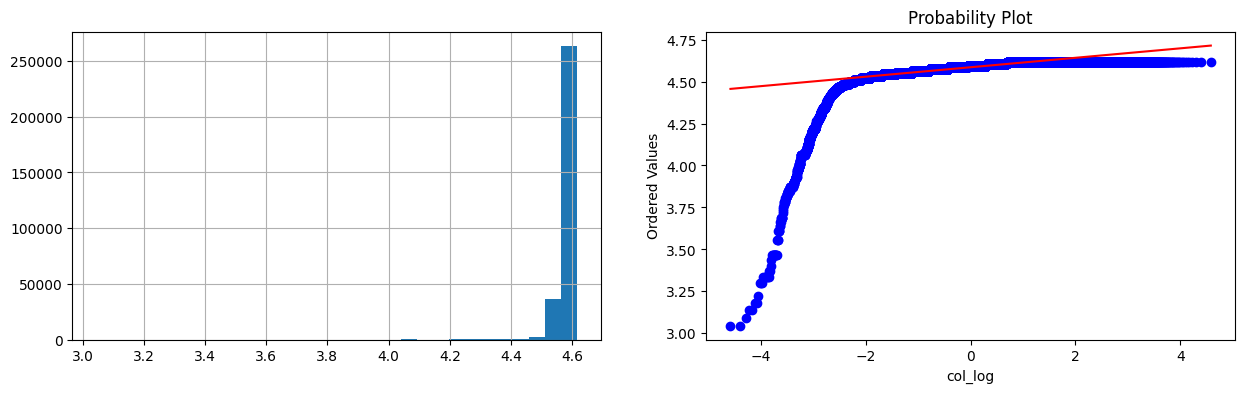

Temp
actual plot


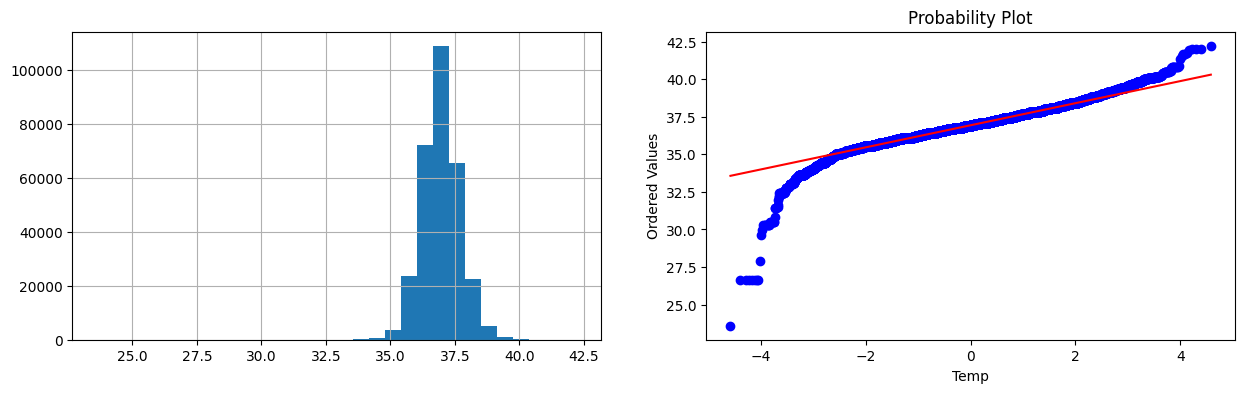

yeojohnson plot


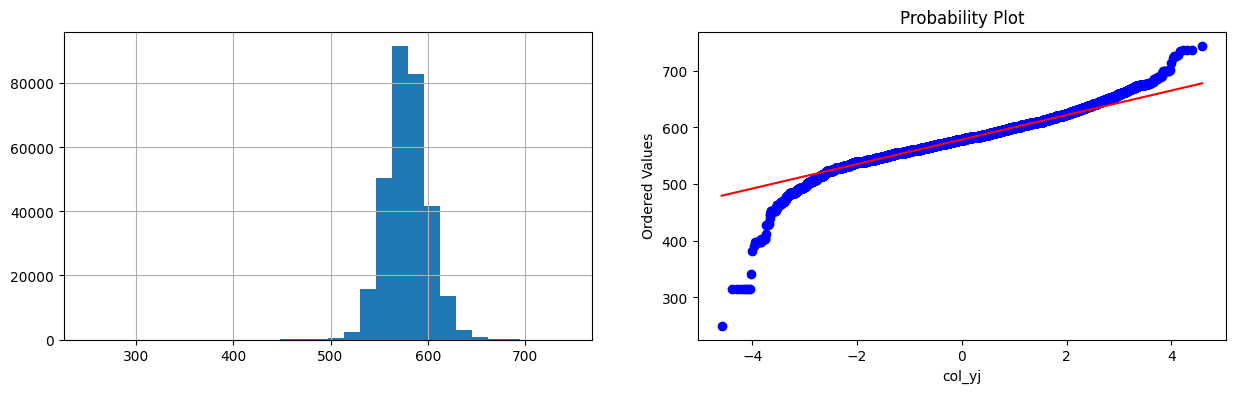

**1/1.5 plot


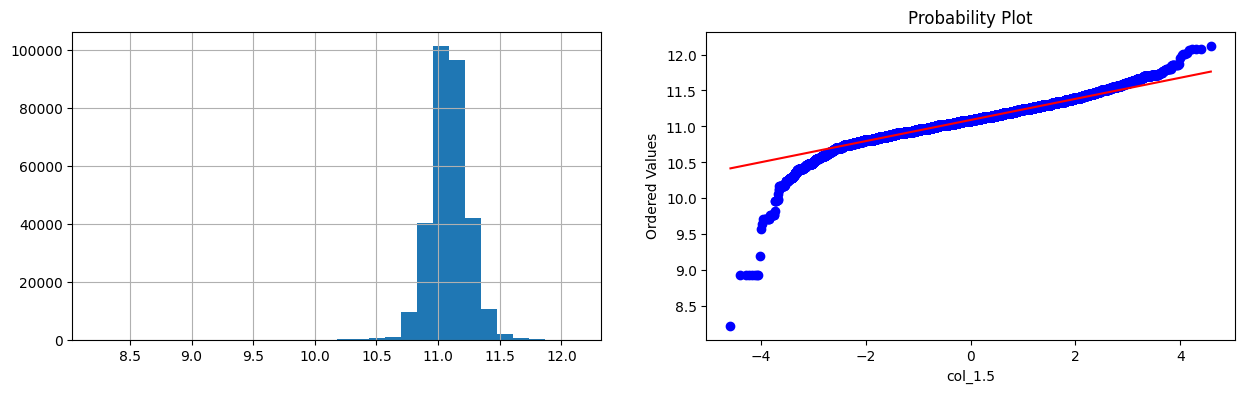

**.5 plot


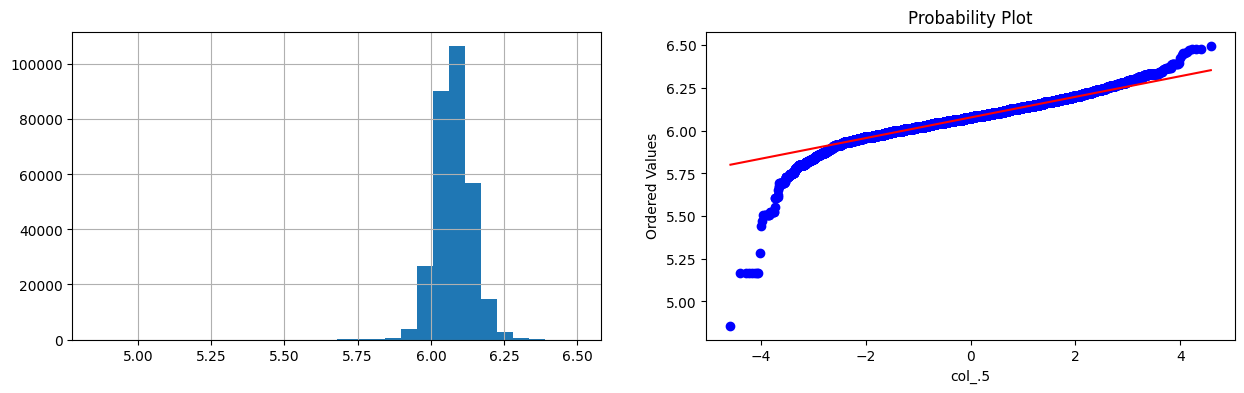

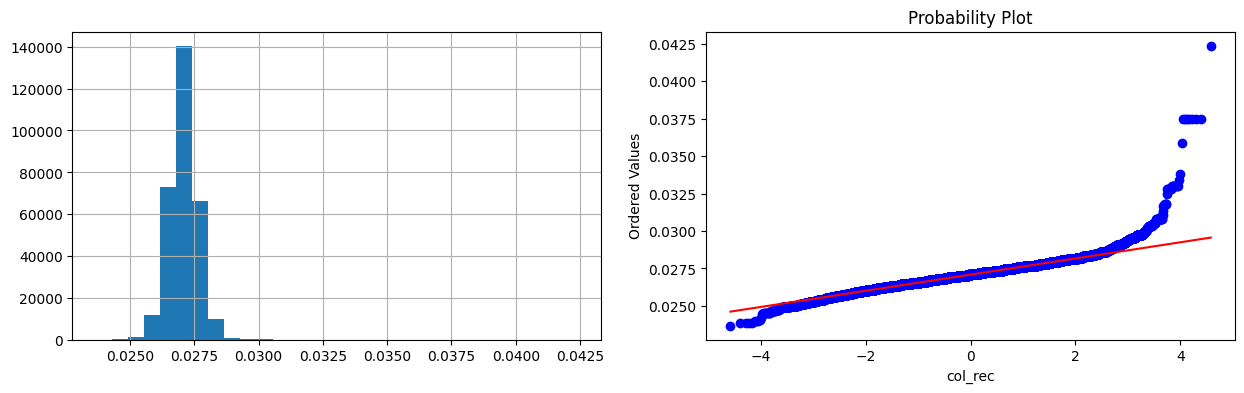

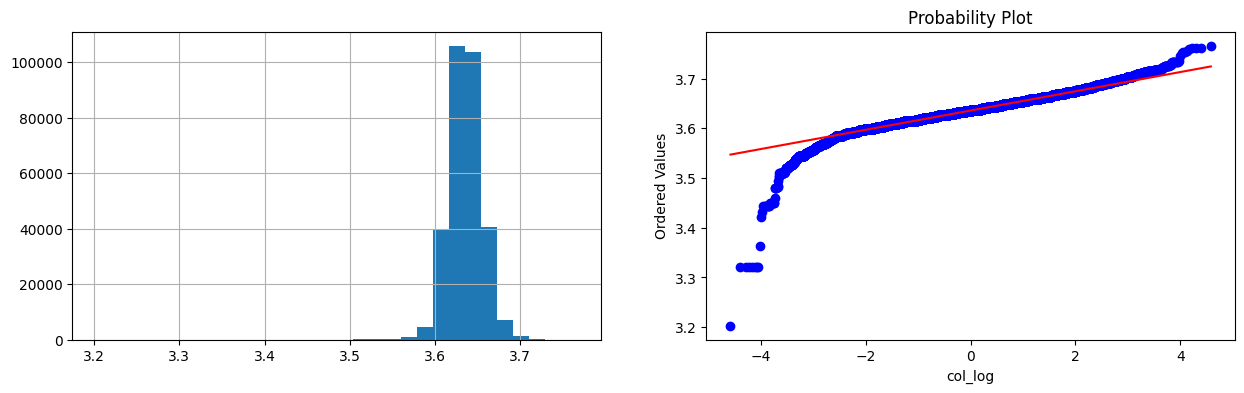

MAP
actual plot


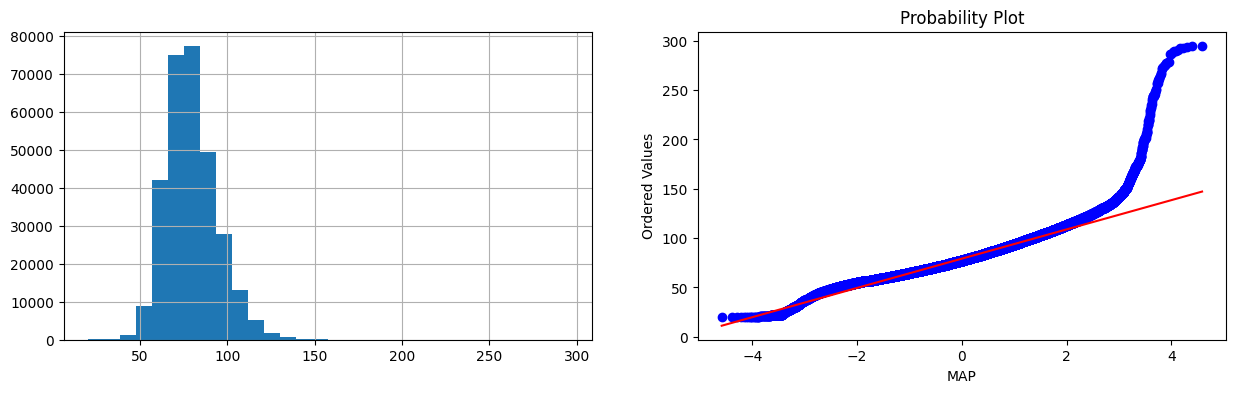

yeojohnson plot


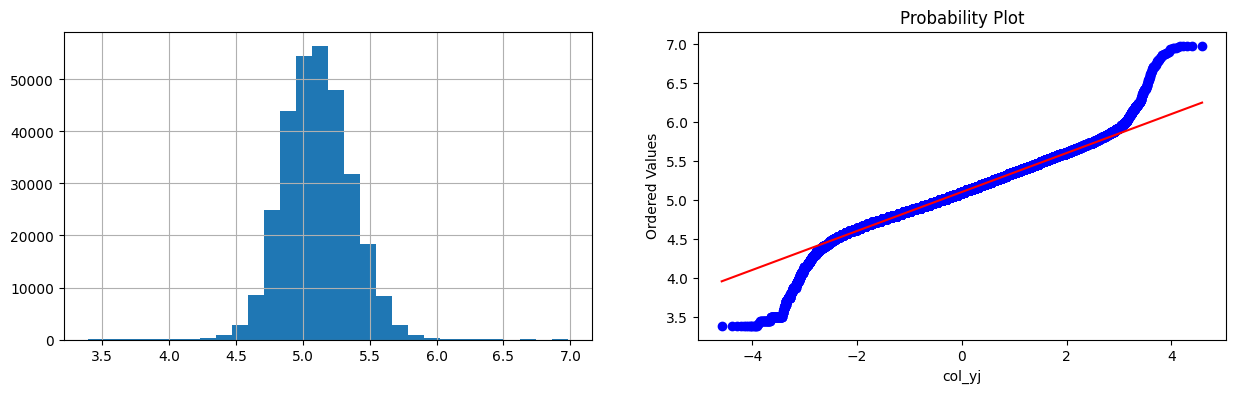

**1/1.5 plot


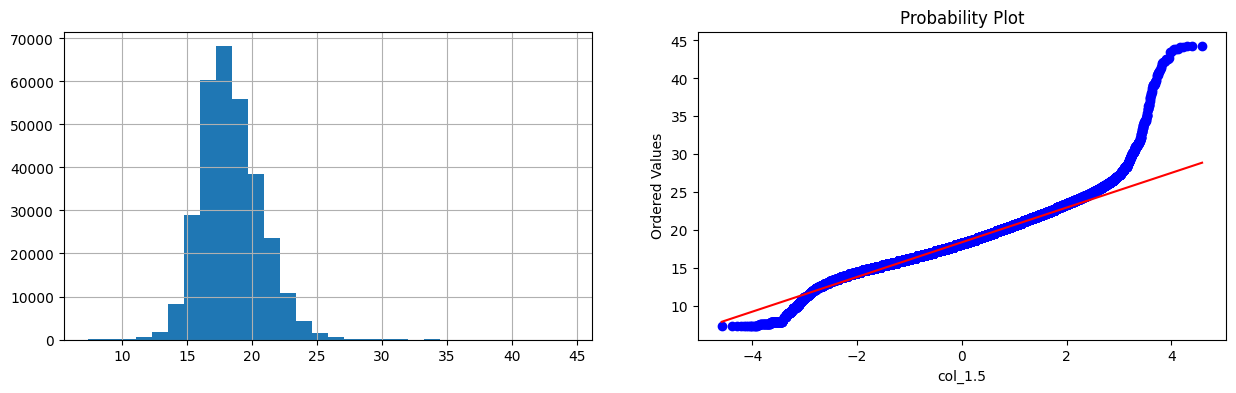

**.5 plot


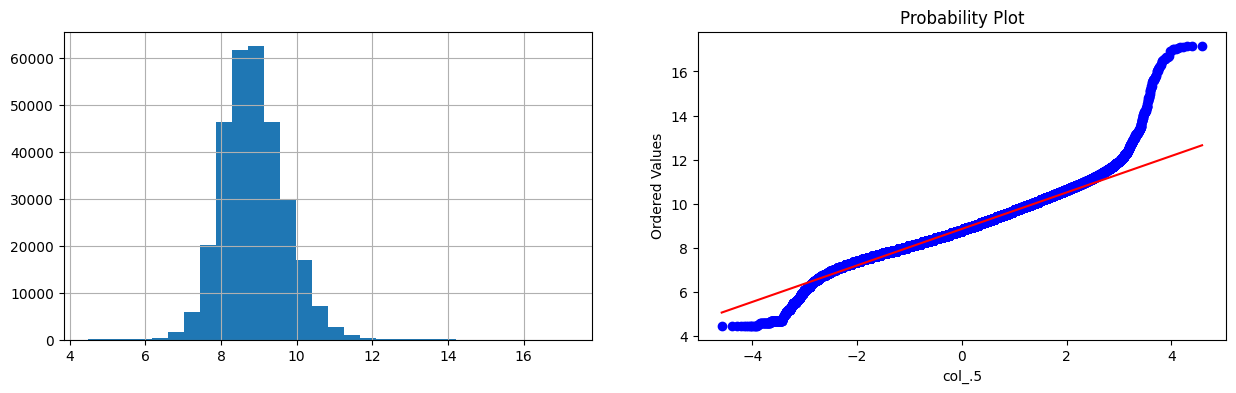

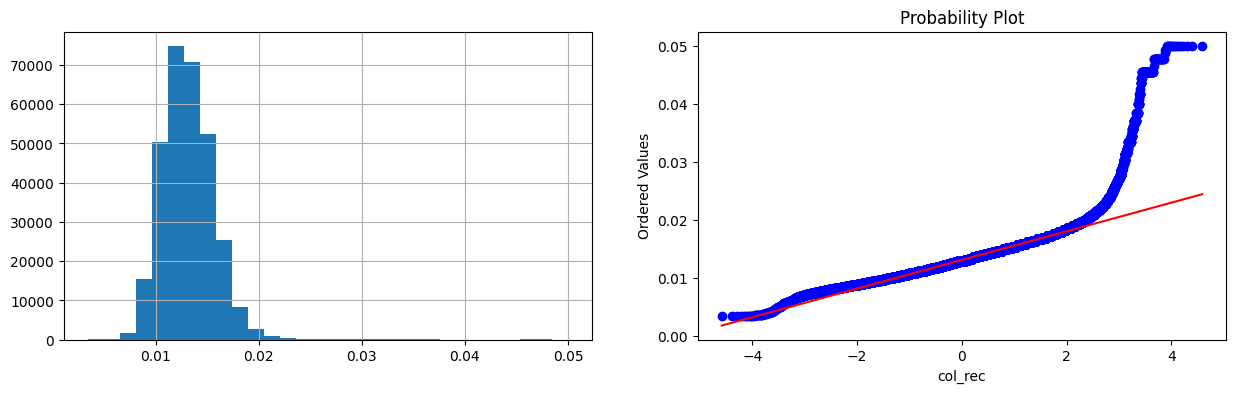

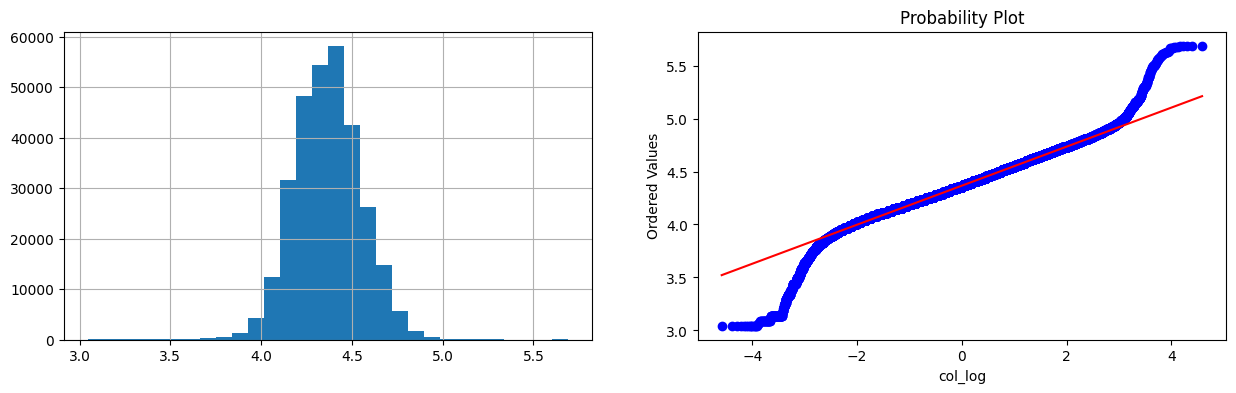

BUN
actual plot


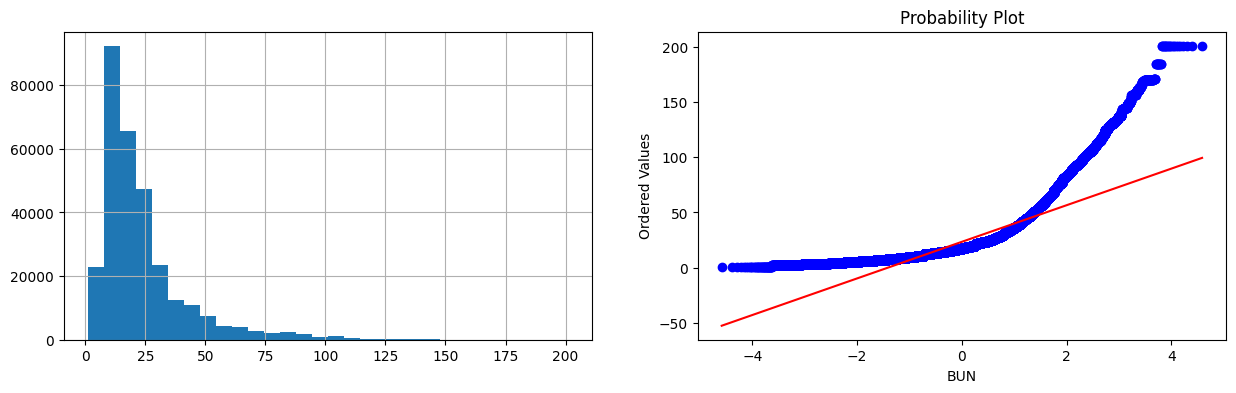

yeojohnson plot


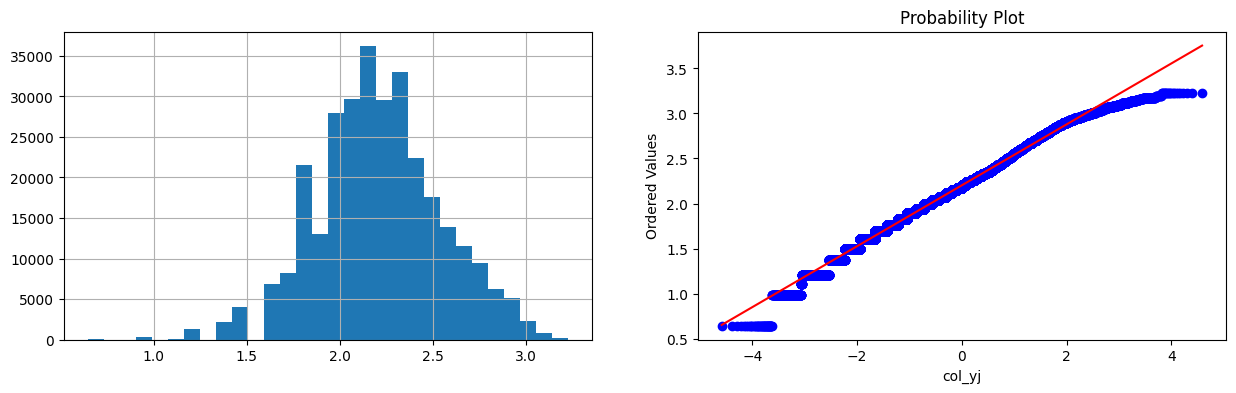

**1/1.5 plot


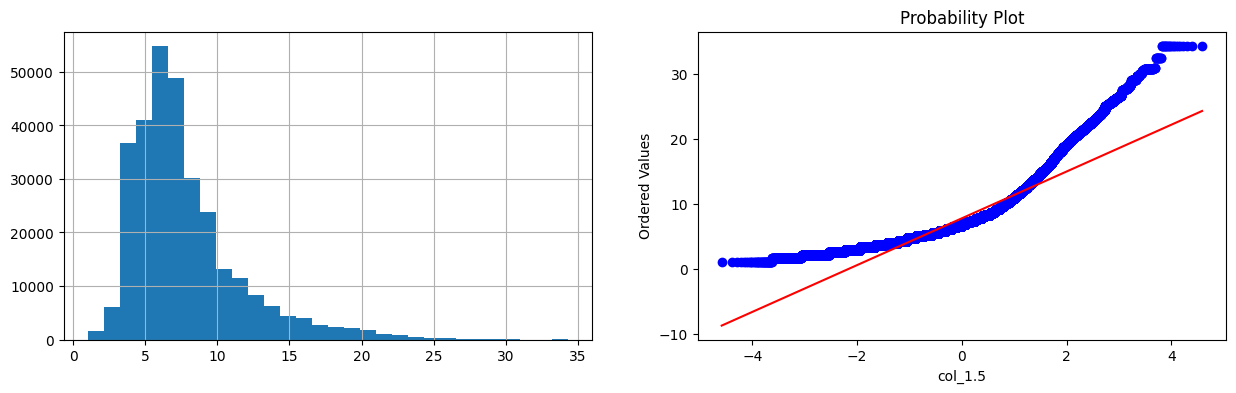

**.5 plot


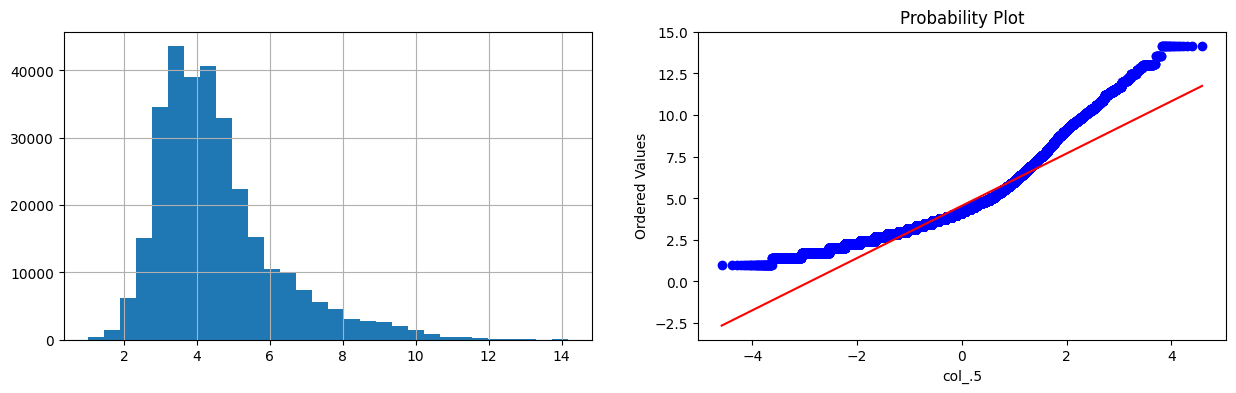

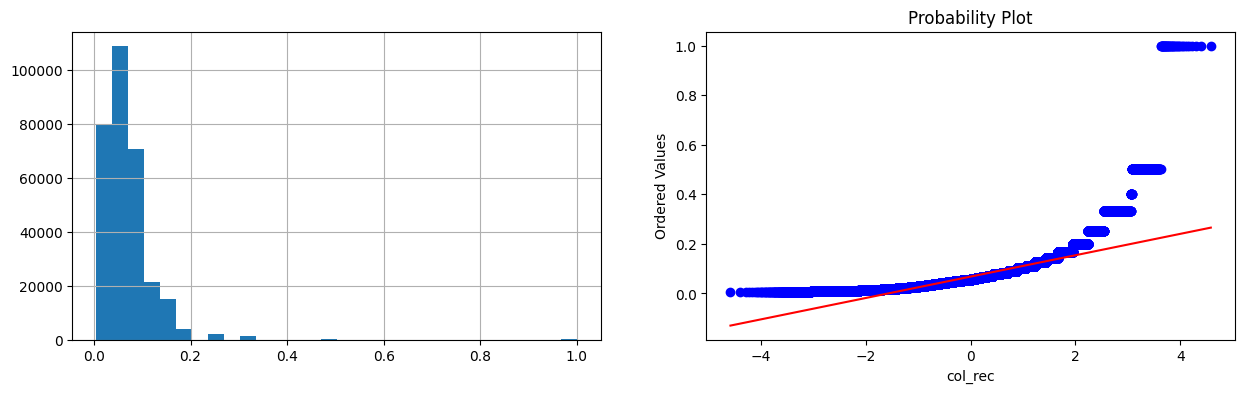

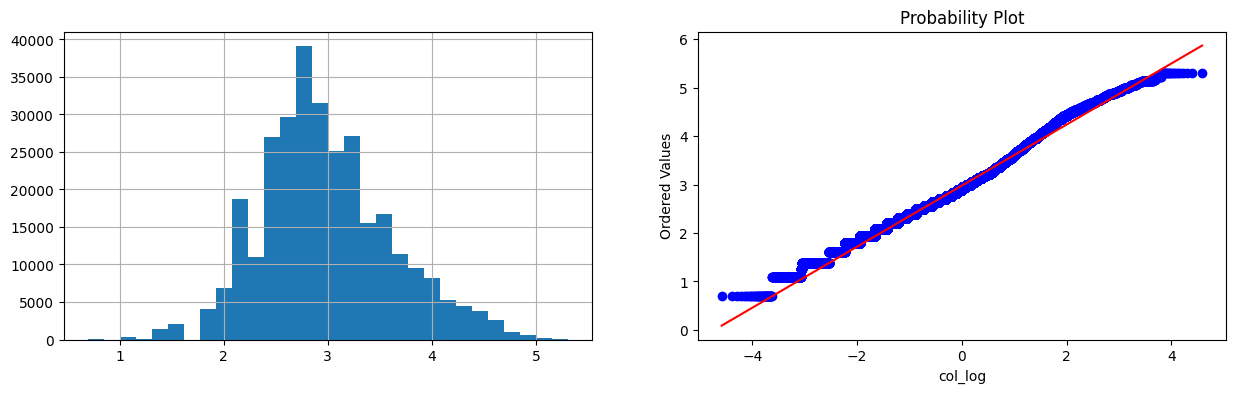

Creatinine
actual plot


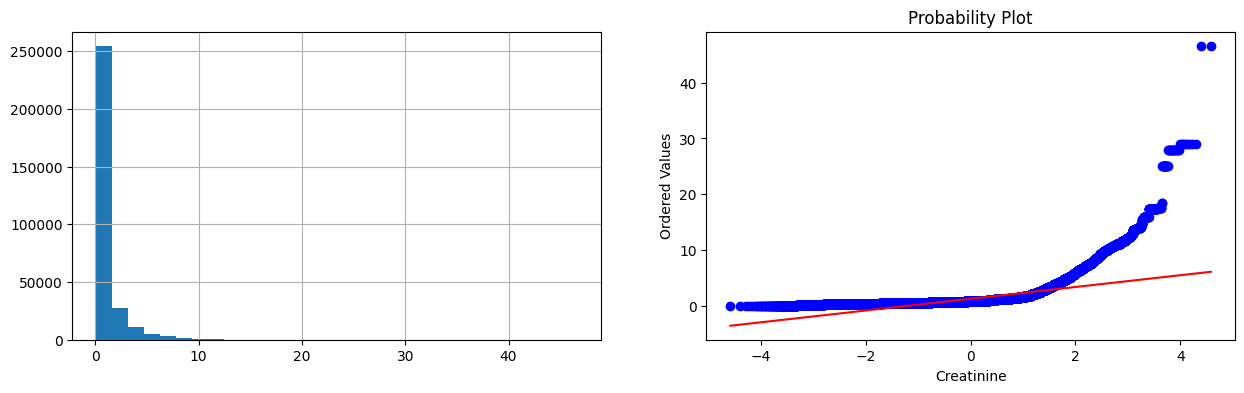

yeojohnson plot


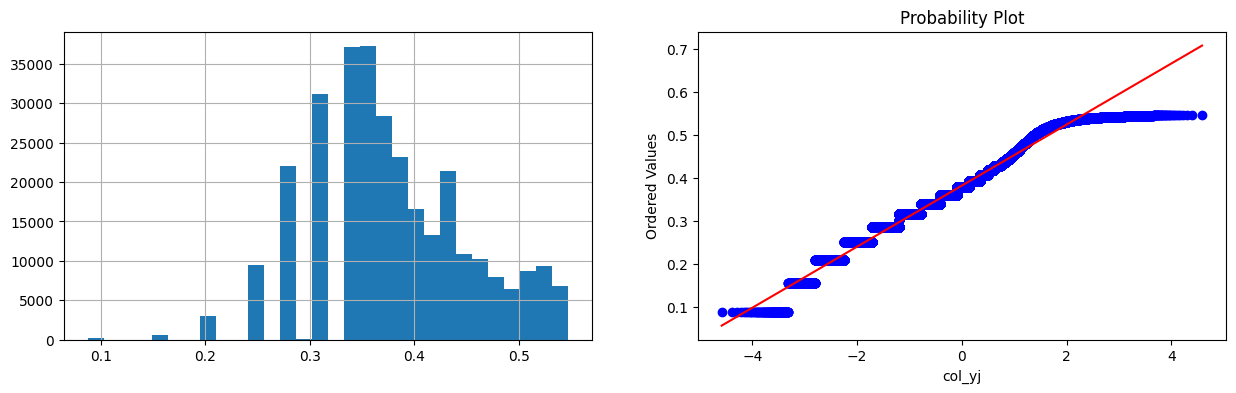

**1/1.5 plot


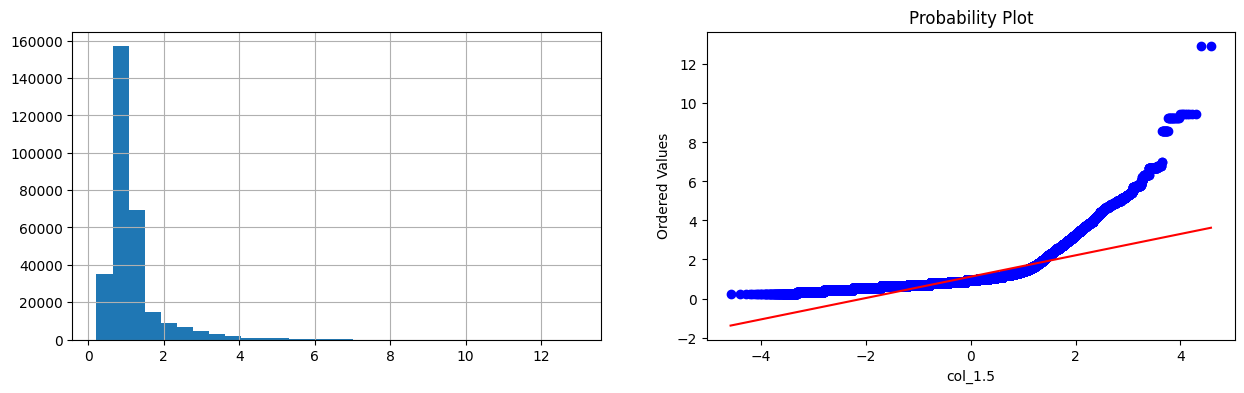

**.5 plot


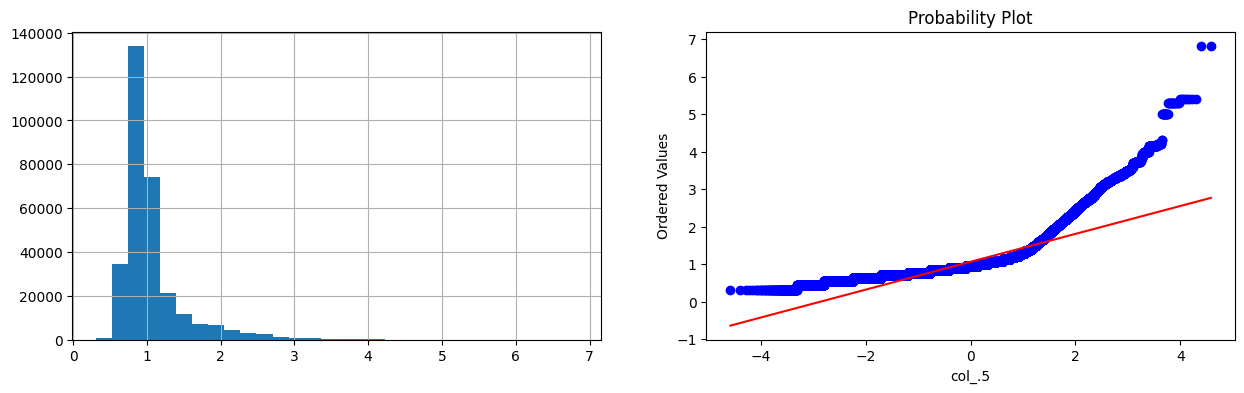

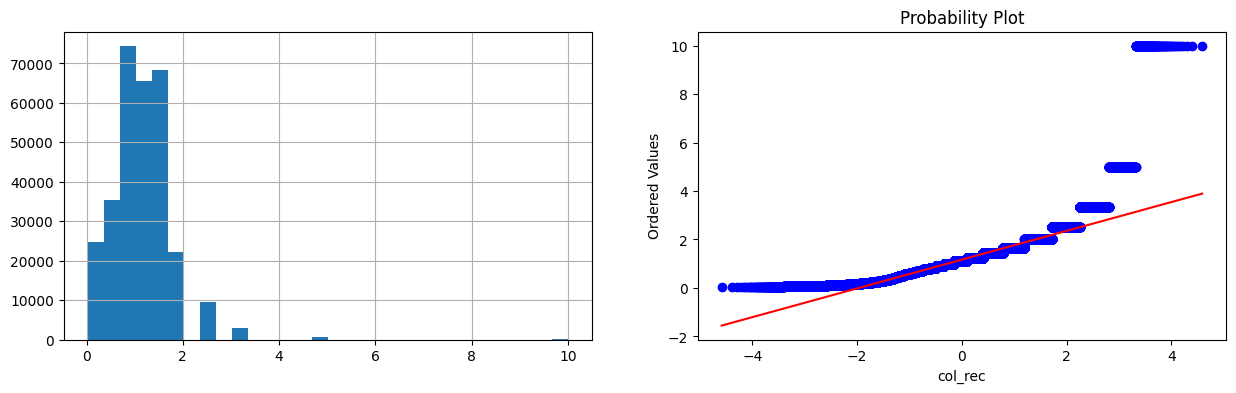

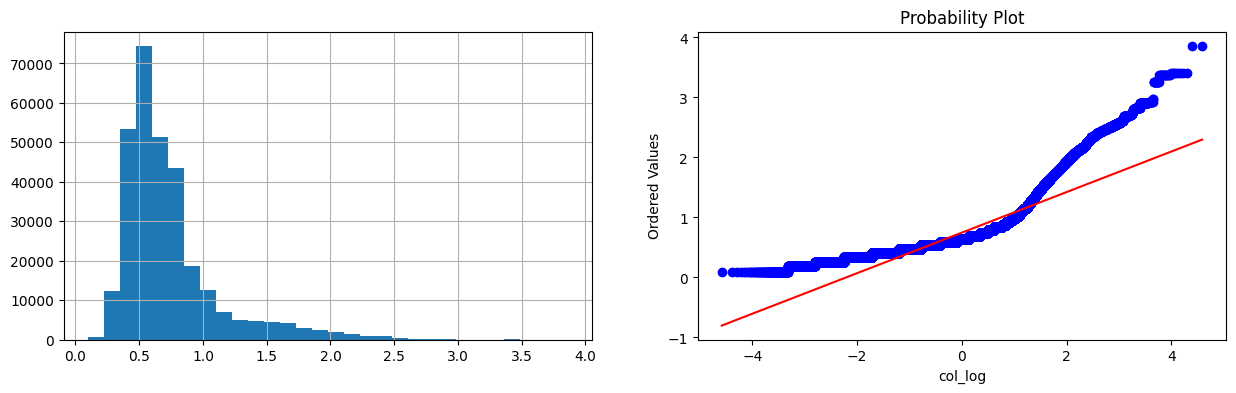

Glucose
actual plot


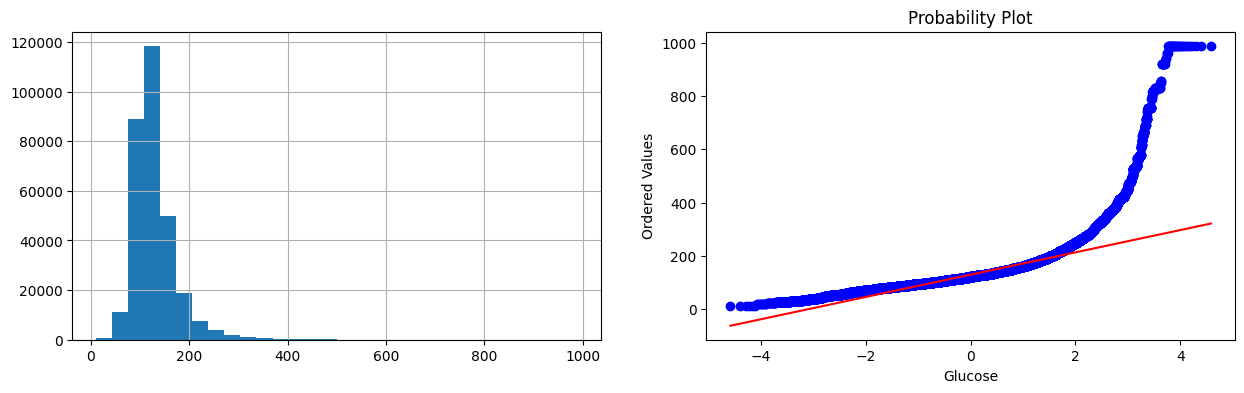

yeojohnson plot


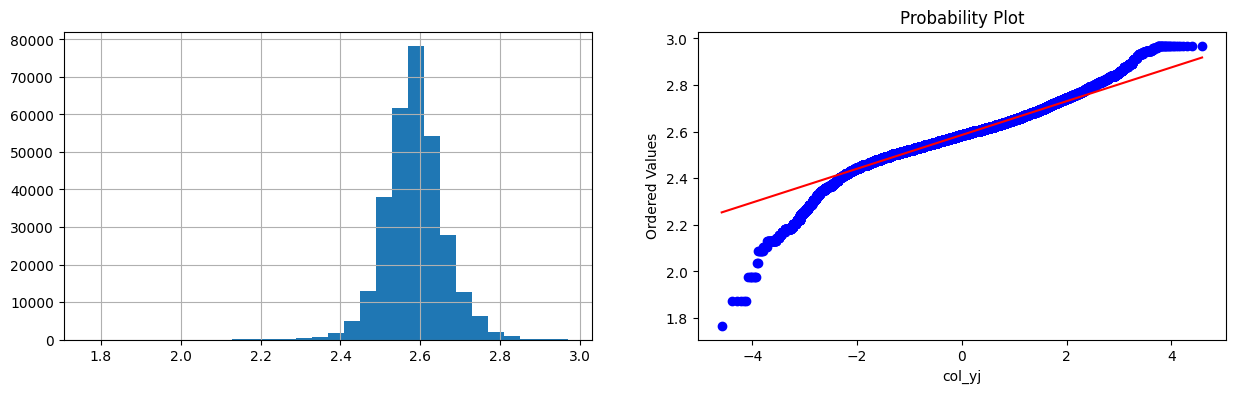

**1/1.5 plot


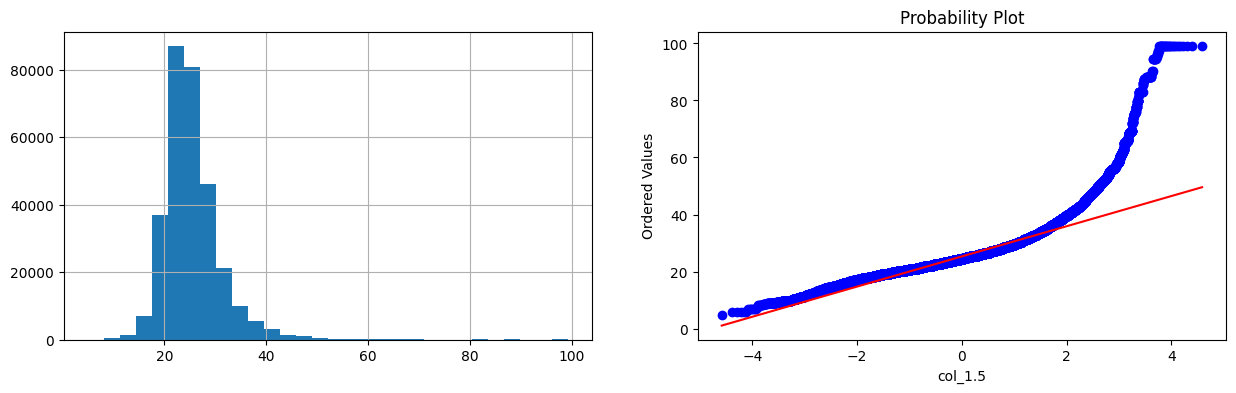

**.5 plot


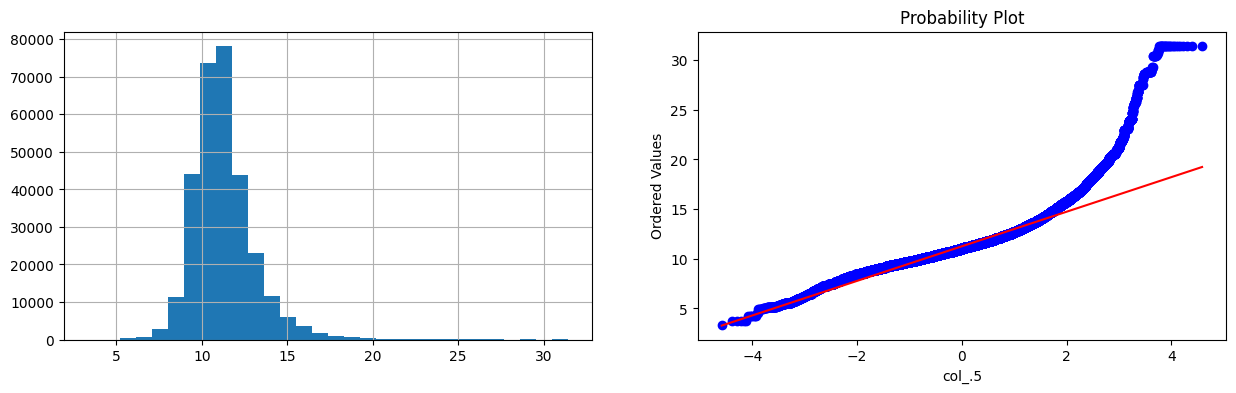

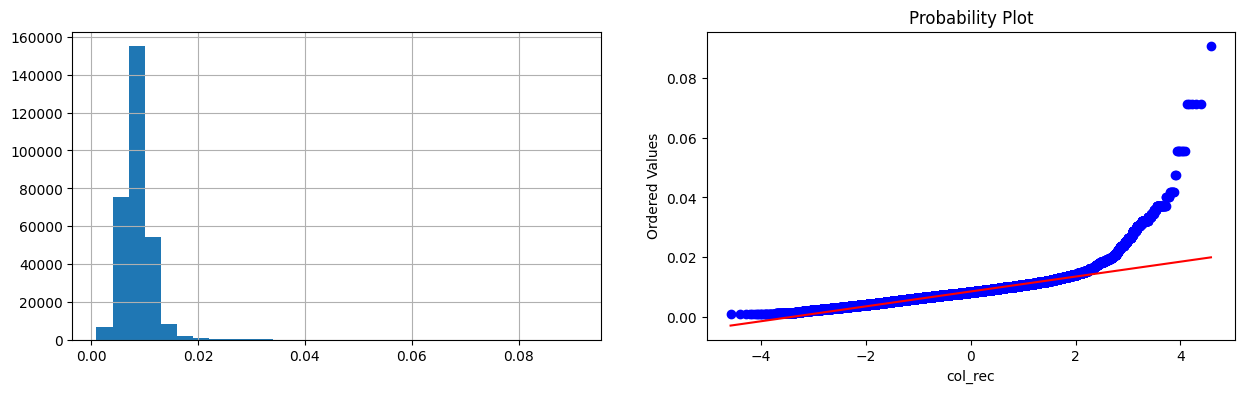

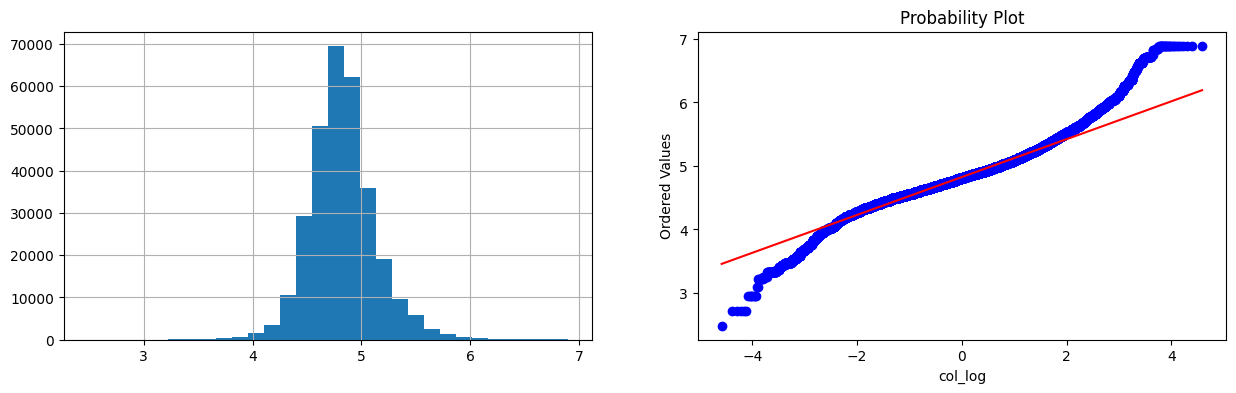

WBC
actual plot


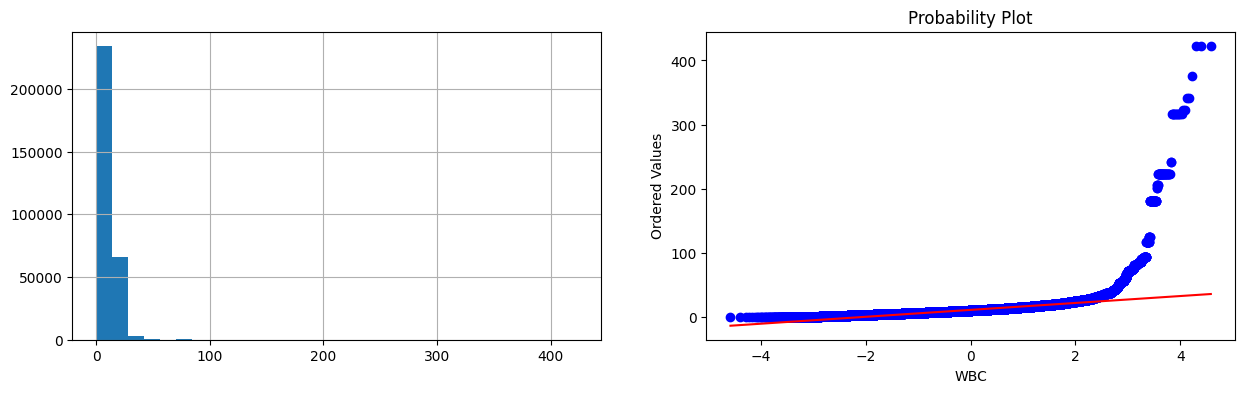

yeojohnson plot


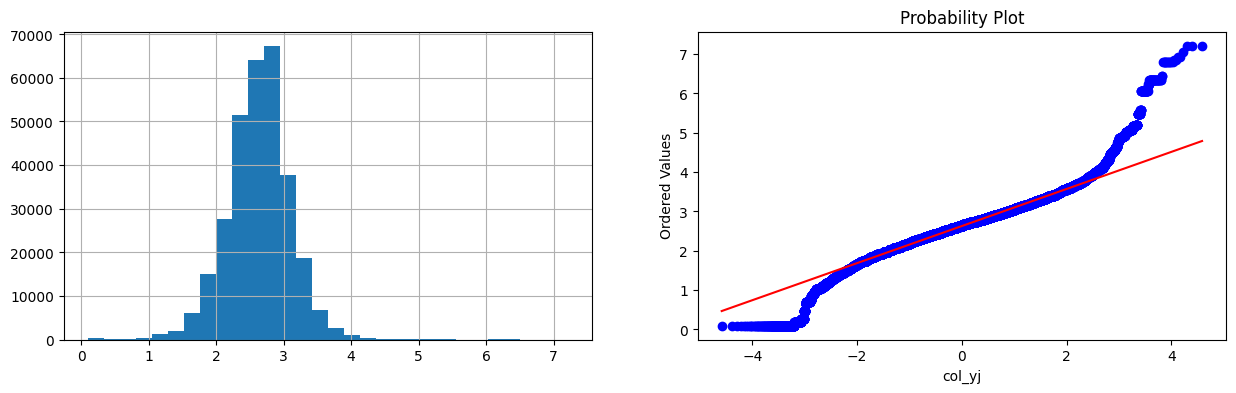

**1/1.5 plot


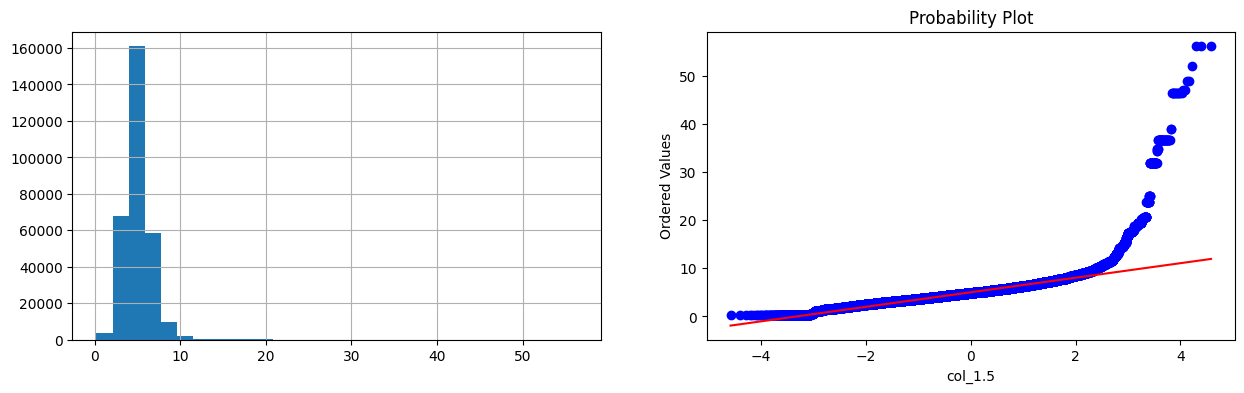

**.5 plot


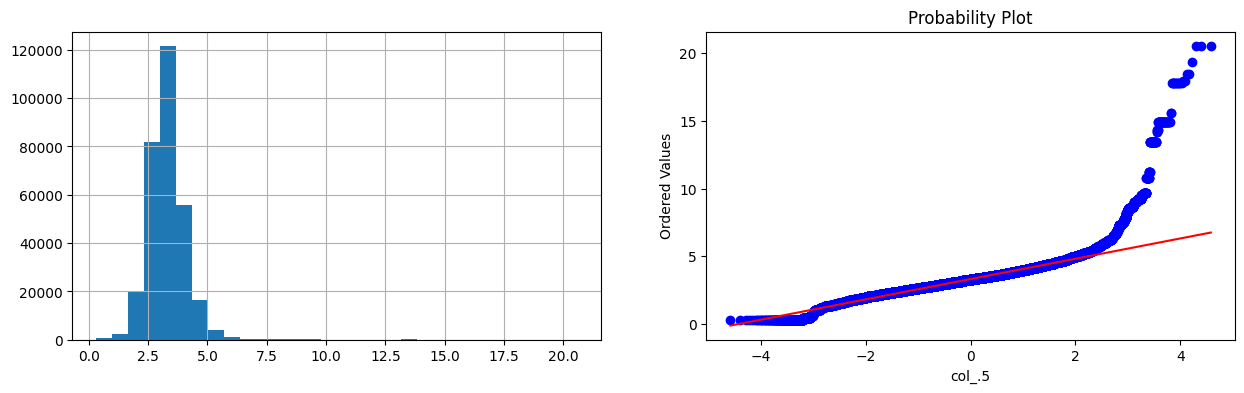

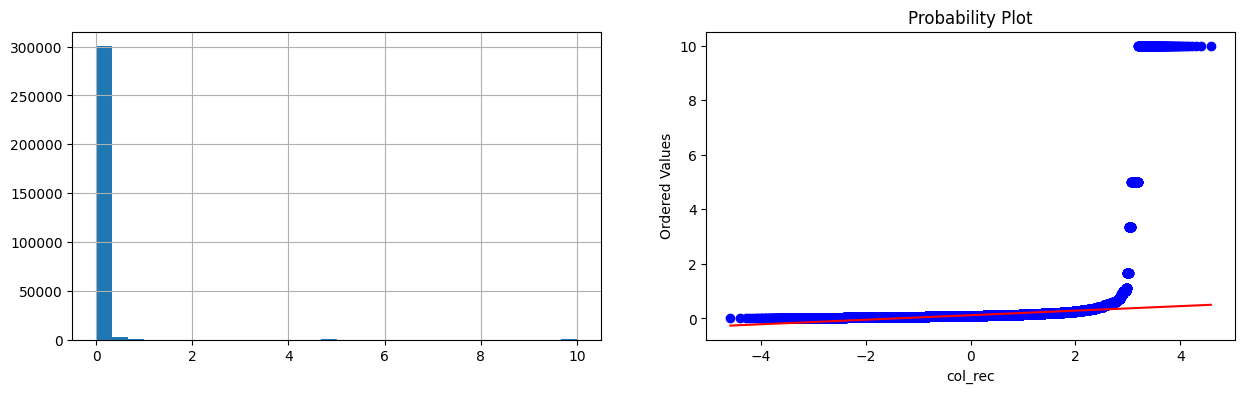

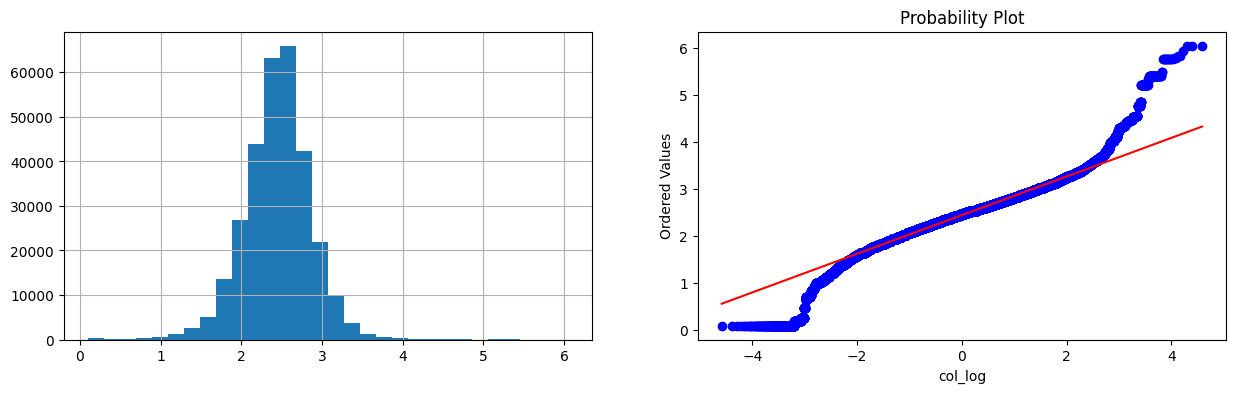

Platelets
actual plot


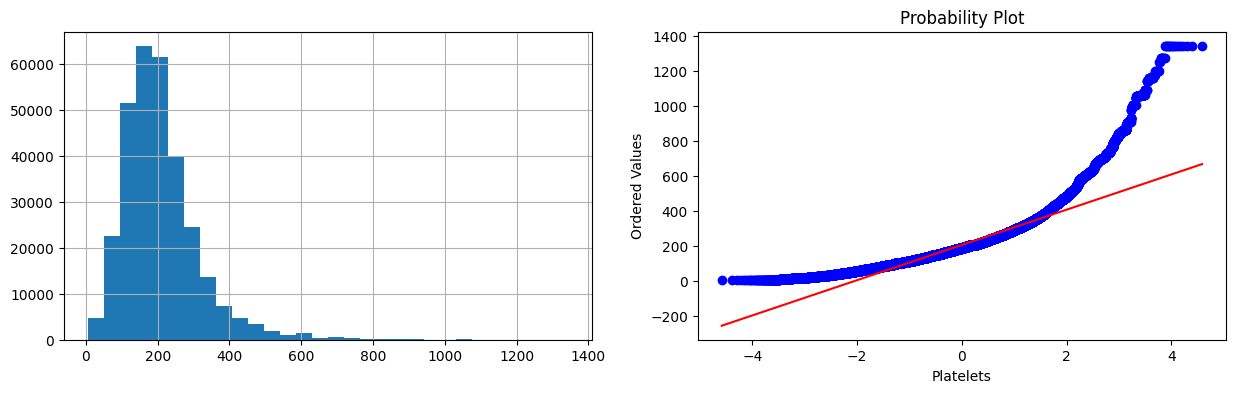

yeojohnson plot


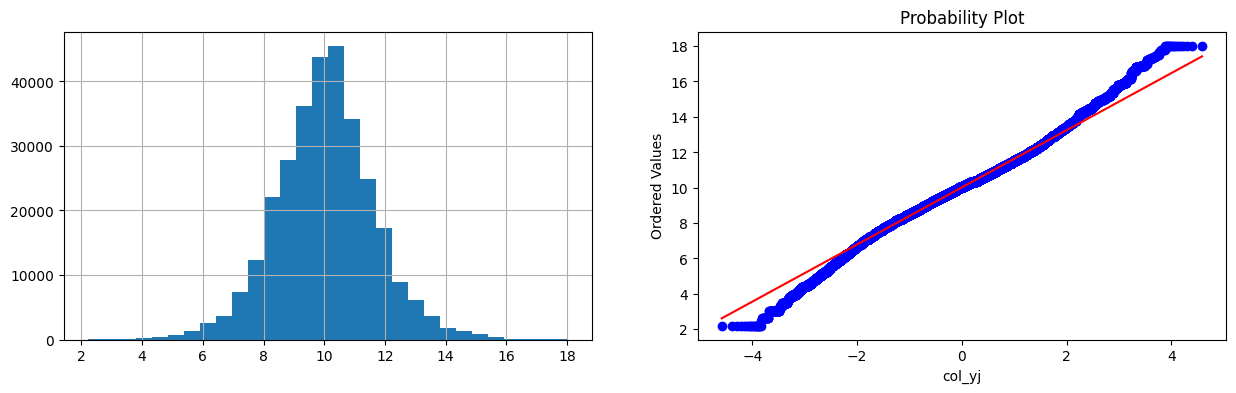

**1/1.5 plot


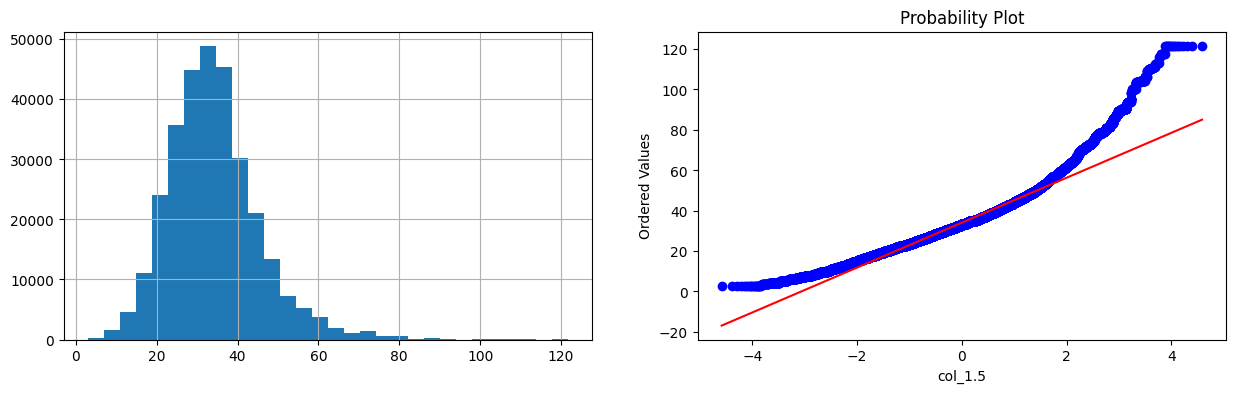

**.5 plot


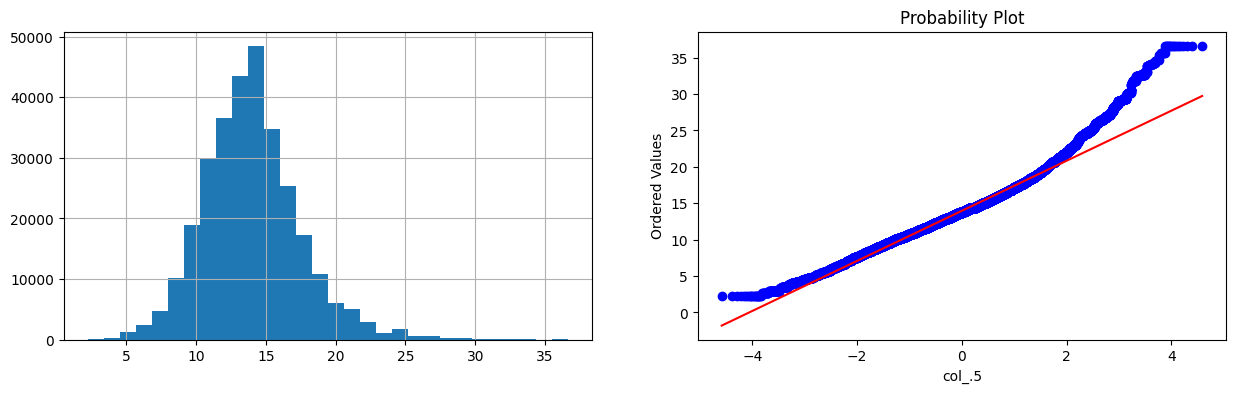

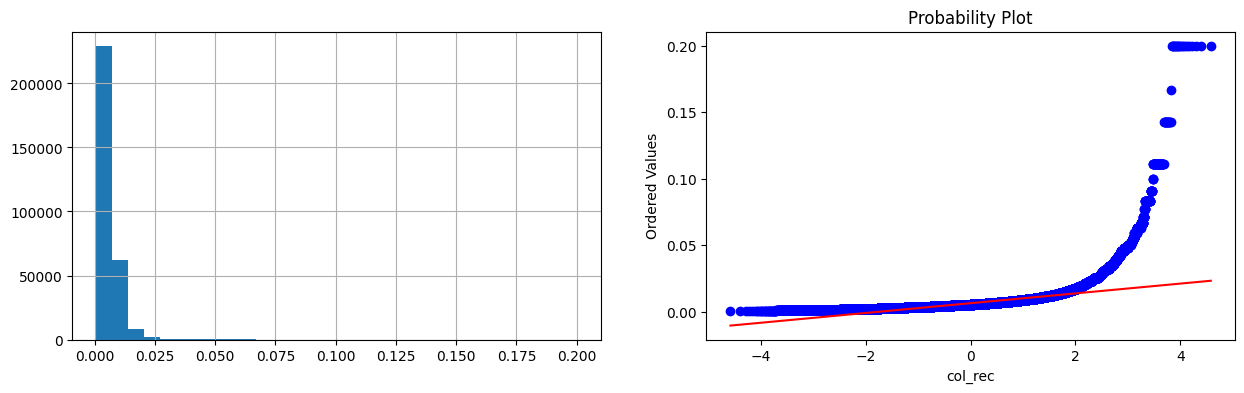

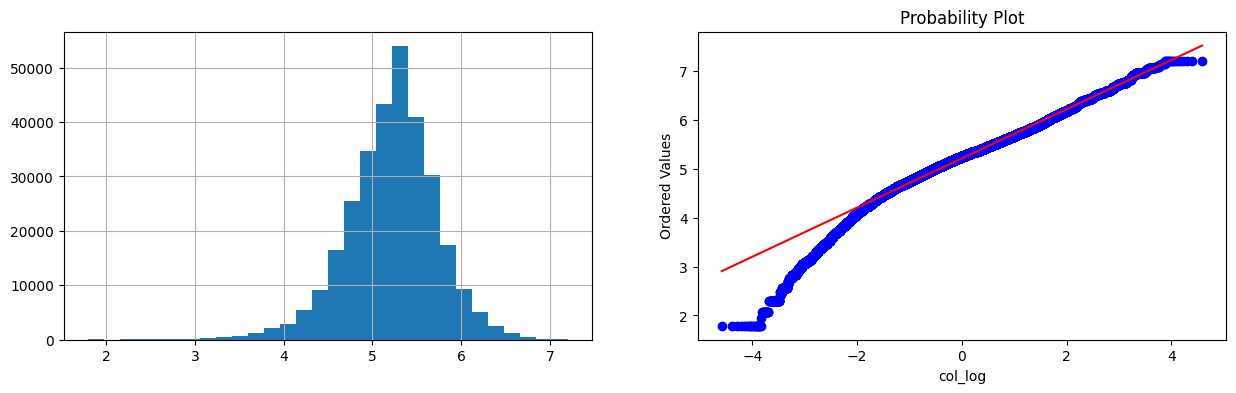

In [ ]:
# try normal distribution
# Now we try to check the distribution of values present in different columns after application of various transformations
# Defining a list of continuous features to test for Gaussian distribution
lst = ['O2Sat', 'Temp', 'MAP', 'BUN', 'Creatinine', 'Glucose', 'WBC', 'Platelets' ]

# Fill remaining NaN values with the mean of each column
for col in lst: # Filling any remaining NaN values in these specific columns with the column's mean
    if col in df_train_impute.columns:
        df_train_impute[col].fillna(df_train_impute[col].mean(), inplace=True)
# Iterating over the list to visualize the transformations for each feature
for i in lst:
  print(i)
  try_gaussian(df_train_impute, i)

In [ ]:
# after application of the above code, some redundant columns got added to the dataframe, which are removed through this line of code
# Removing the temporary transformation columns created by the try_gaussian function to clean the dataframe
df_train_impute = df_train_impute.drop(columns = ['col_yj','col_1.5','col_.5','col_rec','col_log'])

In [ ]:
df_train_impute.head()

Hour     HR  O2Sat   Temp    MAP  Resp   BUN  Chloride  \
Patient_ID                                                                 
1.0        72964     0   97.0   95.0  36.11  75.33  19.0  14.0      85.0   
           72965     1   97.0   95.0  36.11  75.33  19.0  14.0      85.0   
           72966     2   89.0   99.0  36.11  86.00  22.0  14.0      85.0   
           72967     3   90.0   95.0  36.11  91.33  30.0  14.0      85.0   
           72968     4  103.0   88.5  36.11  91.33  24.5  14.0      85.0   

                  Creatinine  Glucose   Hct   Hgb  WBC  Platelets    Age  \
Patient_ID                                                                 
1.0        72964         0.7    193.0  37.2  12.5  5.7      317.0  83.14   
           72965         0.7    193.0  37.2  12.5  5.7      317.0  83.14   
           72966         0.7    193.0  37.2  12.5  5.7      317.0  83.14   
           72967         0.7    193.0  37.2  12.5  5.7      317.0  83.14   
           72968         0.7    193.0  37.2  12.5  5.7      317.0  83.14   

                  HospAdmTime  ICULOS  SepsisLabel   0.0    1.0  
Patient_ID                                                       
1.0        72964        -0.03     1.0          0.0  True  False  
           72965        -0.03     2.0          0.0  True  False  
           72966        -0.03     3.0          0.0  True  False  
           72967        -0.03     4.0          0.0  True  False  
           72968        -0.03     5.0          0.0  True  False

In [ ]:
# by oserving different plots, it can be concluded that only log was somewhat effective and that too for MAP, BUN, Creatinine, Glucose, WBC & Plateletes
# therefore applying log transformations on the above columns
# Based on observations, log transformation was the most effective for specific columns
columns_normalized = ['MAP', 'BUN', 'Creatinine', 'Glucose', 'WBC', 'Platelets' ]
for i in columns_normalized: # Applying log transformation permanently to these columns
  df_train_impute[i] = np.log(df_train_impute[i]+1)

In [ ]:
df_train_impute.head()

Hour     HR  O2Sat   Temp       MAP  Resp      BUN  \
Patient_ID                                                             
1.0        72964     0   97.0   95.0  36.11  4.335066  19.0  2.70805   
           72965     1   97.0   95.0  36.11  4.335066  19.0  2.70805   
           72966     2   89.0   99.0  36.11  4.465908  22.0  2.70805   
           72967     3   90.0   95.0  36.11  4.525369  30.0  2.70805   
           72968     4  103.0   88.5  36.11  4.525369  24.5  2.70805   

                  Chloride  Creatinine   Glucose   Hct   Hgb       WBC  \
Patient_ID                                                               
1.0        72964      85.0    0.530628  5.267858  37.2  12.5  1.902108   
           72965      85.0    0.530628  5.267858  37.2  12.5  1.902108   
           72966      85.0    0.530628  5.267858  37.2  12.5  1.902108   
           72967      85.0    0.530628  5.267858  37.2  12.5  1.902108   
           72968      85.0    0.530628  5.267858  37.2  12.5  1.902108   

                  Platelets    Age  HospAdmTime  ICULOS  SepsisLabel   0.0  \
Patient_ID                                                                   
1.0        72964   5.762051  83.14        -0.03     1.0          0.0  True   
           72965   5.762051  83.14        -0.03     2.0          0.0  True   
           72966   5.762051  83.14        -0.03     3.0          0.0  True   
           72967   5.762051  83.14        -0.03     4.0          0.0  True   
           72968   5.762051  83.14        -0.03     5.0          0.0  True   

                    1.0  
Patient_ID               
1.0        72964  False  
           72965  False  
           72966  False  
           72967  False  
           72968  False

In [ ]:
# standard normalization
# Initializing StandardScaler to standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()
df_train_impute[['HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride', # Applying the scaler to the vital signs and lab results columns
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets']] = scaler.fit_transform(df_train_impute[['HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride',
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets']])
df_train_impute.head()

Hour        HR     O2Sat      Temp       MAP      Resp  \
Patient_ID                                                                 
1.0        72964     0  0.715334 -0.686316 -1.112794 -0.171139  0.055400   
           72965     1  0.715334 -0.686316 -1.112794 -0.171139  0.055400   
           72966     2  0.247694  0.566584 -1.112794  0.534374  0.614607   
           72967     3  0.306149 -0.686316 -1.112794  0.854994  2.105825   
           72968     4  1.066063 -2.722279 -1.112794  0.854994  1.080613   

                       BUN  Chloride  Creatinine   Glucose       Hct  \
Patient_ID                                                             
1.0        72964 -0.425596 -3.678746   -0.563764  1.461788  1.197136   
           72965 -0.425596 -3.678746   -0.563764  1.461788  1.197136   
           72966 -0.425596 -3.678746   -0.563764  1.461788  1.197136   
           72967 -0.425596 -3.678746   -0.563764  1.461788  1.197136   
           72968 -0.425596 -3.678746   -0.563764  1.461788  1.197136   

                       Hgb       WBC  Platelets    Age  HospAdmTime  ICULOS  \
Patient_ID                                                                    
1.0        72964  1.083153 -1.302285    1.07504  83.14        -0.03     1.0   
           72965  1.083153 -1.302285    1.07504  83.14        -0.03     2.0   
           72966  1.083153 -1.302285    1.07504  83.14        -0.03     3.0   
           72967  1.083153 -1.302285    1.07504  83.14        -0.03     4.0   
           72968  1.083153 -1.302285    1.07504  83.14        -0.03     5.0   

                  SepsisLabel   0.0    1.0  
Patient_ID                                  
1.0        72964          0.0  True  False  
           72965          0.0  True  False  
           72966          0.0  True  False  
           72967          0.0  True  False  
           72968          0.0  True  False

In [ ]:
df_train_impute = df_train_impute.dropna() # Dropping any remaining rows that still contain null values to ensure a clean dataset for training

In [ ]:
null_values = df_train_impute.isnull().mean()*100 # Verifying that no missing values remain
null_values

Hour           0.0
HR             0.0
O2Sat          0.0
Temp           0.0
MAP            0.0
Resp           0.0
BUN            0.0
Chloride       0.0
Creatinine     0.0
Glucose        0.0
Hct            0.0
Hgb            0.0
WBC            0.0
Platelets      0.0
Age            0.0
HospAdmTime    0.0
ICULOS         0.0
SepsisLabel    0.0
0.0            0.0
1.0            0.0
dtype: float64

# Model Building

In [ ]:
# this function will transform the dataframe (for final testing) in the compatible
# format for the input of the model
# this will make it easier to get the dataframe ready in a single go for prediction
# Defining a comprehensive function to preprocess raw testing data identically to the training data
def get_data_ready(df):
  columns_drop={'Unnamed: 0','SBP','DBP','EtCO2','BaseExcess', 'HCO3','pH','PaCO2','Alkalinephos', 'Calcium','Magnesium',
  'Phosphate','Potassium','PTT','Fibrinogen','Unit1','Unit2'} # Defining redundant columns to drop
  df = df.assign(Unit=df['Unit1'] + df['Unit2']) # Combining units
  # dropping columns based on redundancy
  df = df.drop(columns=columns_drop) # Dropping columns based on redundancy
  grouped_by_patient = df.groupby('Patient_ID') # Grouping by patient to prevent data leakage during imputation
  # imputing backfill and forward fill
  df = grouped_by_patient.apply(lambda x: x.bfill().ffill()) # Imputing with backfill and forward fill per patient
  # dropping all the columns with null values more than 25% and patient_id
  null_col = ['TroponinI', 'Bilirubin_direct', 'AST', 'Bilirubin_total', 'Lactate', 'SaO2', 'FiO2','Unit', 'Patient_ID'] # Defining columns to drop due to high null value percentage (>25%)
  df = df.drop(columns=null_col)
  # gaussian transformation
  columns_normalized = ['MAP', 'BUN', 'Creatinine', 'Glucose', 'WBC', 'Platelets' ] # Applying gaussian (log) transformation to specific continuous variables
  for i in columns_normalized:
    df[i] = np.log(df[i]+1)
  # normailizing
  scaler = StandardScaler() # Standardizing the features
  df[['HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride',
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets']] = scaler.fit_transform(df[['HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride',
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets']])
  # onehot encoding the gender
  one_hot = pd.get_dummies(df['Gender']) # One-hot encoding the gender column
  df = df.join(one_hot)
  df = df.drop('Gender', axis=1)
  df = df.dropna() # Dropping any residual missing values
  # Converting column names to strings to avoid type issues during modeling
  df.columns = df.columns.astype(str) # Convert column names to strings
  return df

In [ ]:
# this fucntion calculates different evaluation parameters of a model
# Defining a function to calculate and print various classification evaluation metrics
def evaluate_model(y_true,y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  print("Accuracy:", accuracy)
  precision = precision_score(y_true, y_pred)
  print("Precision:", precision)
  recall = recall_score(y_true, y_pred)
  print("Recall:", recall)
  f1 = f1_score(y_true, y_pred)
  print("F1 Score:", f1)
  auc = roc_auc_score(y_true, y_pred)
  print("AUC-ROC:", auc)
  mae = mean_absolute_error(y_true, y_pred)
  print("Mean Absolute Error:", mae)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  print("Root Mean Squared Error:", rmse)
  cm = confusion_matrix(y_true, y_pred) # Generating and plotting the confusion matrix
  sns.heatmap(cm, annot=True, fmt='d')
  plt.show()

In [ ]:
# checking the distribution of data points between the two classes
# Separating the dataset into majority (non-sepsis) and minority (sepsis) classes to check class distribution
majority_class = df_train_impute[df_train_impute['SepsisLabel'] == 0]
minority_class = df_train_impute[df_train_impute['SepsisLabel'] == 1]
# Printing the counts to observe the data imbalance
print('number of sepsis label 1 is {}'.format(len(minority_class)))
print('while number of sepsis label 0 is {}'.format(len(majority_class)))

number of sepsis label 1 is 6149
while number of sepsis label 0 is 291724


So, this shows a clear imbalance between sepsis label 1 and label 0, to deal with this, we did undersampling.

In [ ]:
# Undersampling
# Undersampling the majority class to balance the dataset (taking twice the number of the minority class)
majority_class_subset = majority_class.sample(n=2*len(minority_class))
# Concatenating the sampled majority class with the minority class to form the new training set
df_train_impute = pd.concat([majority_class_subset, minority_class])

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


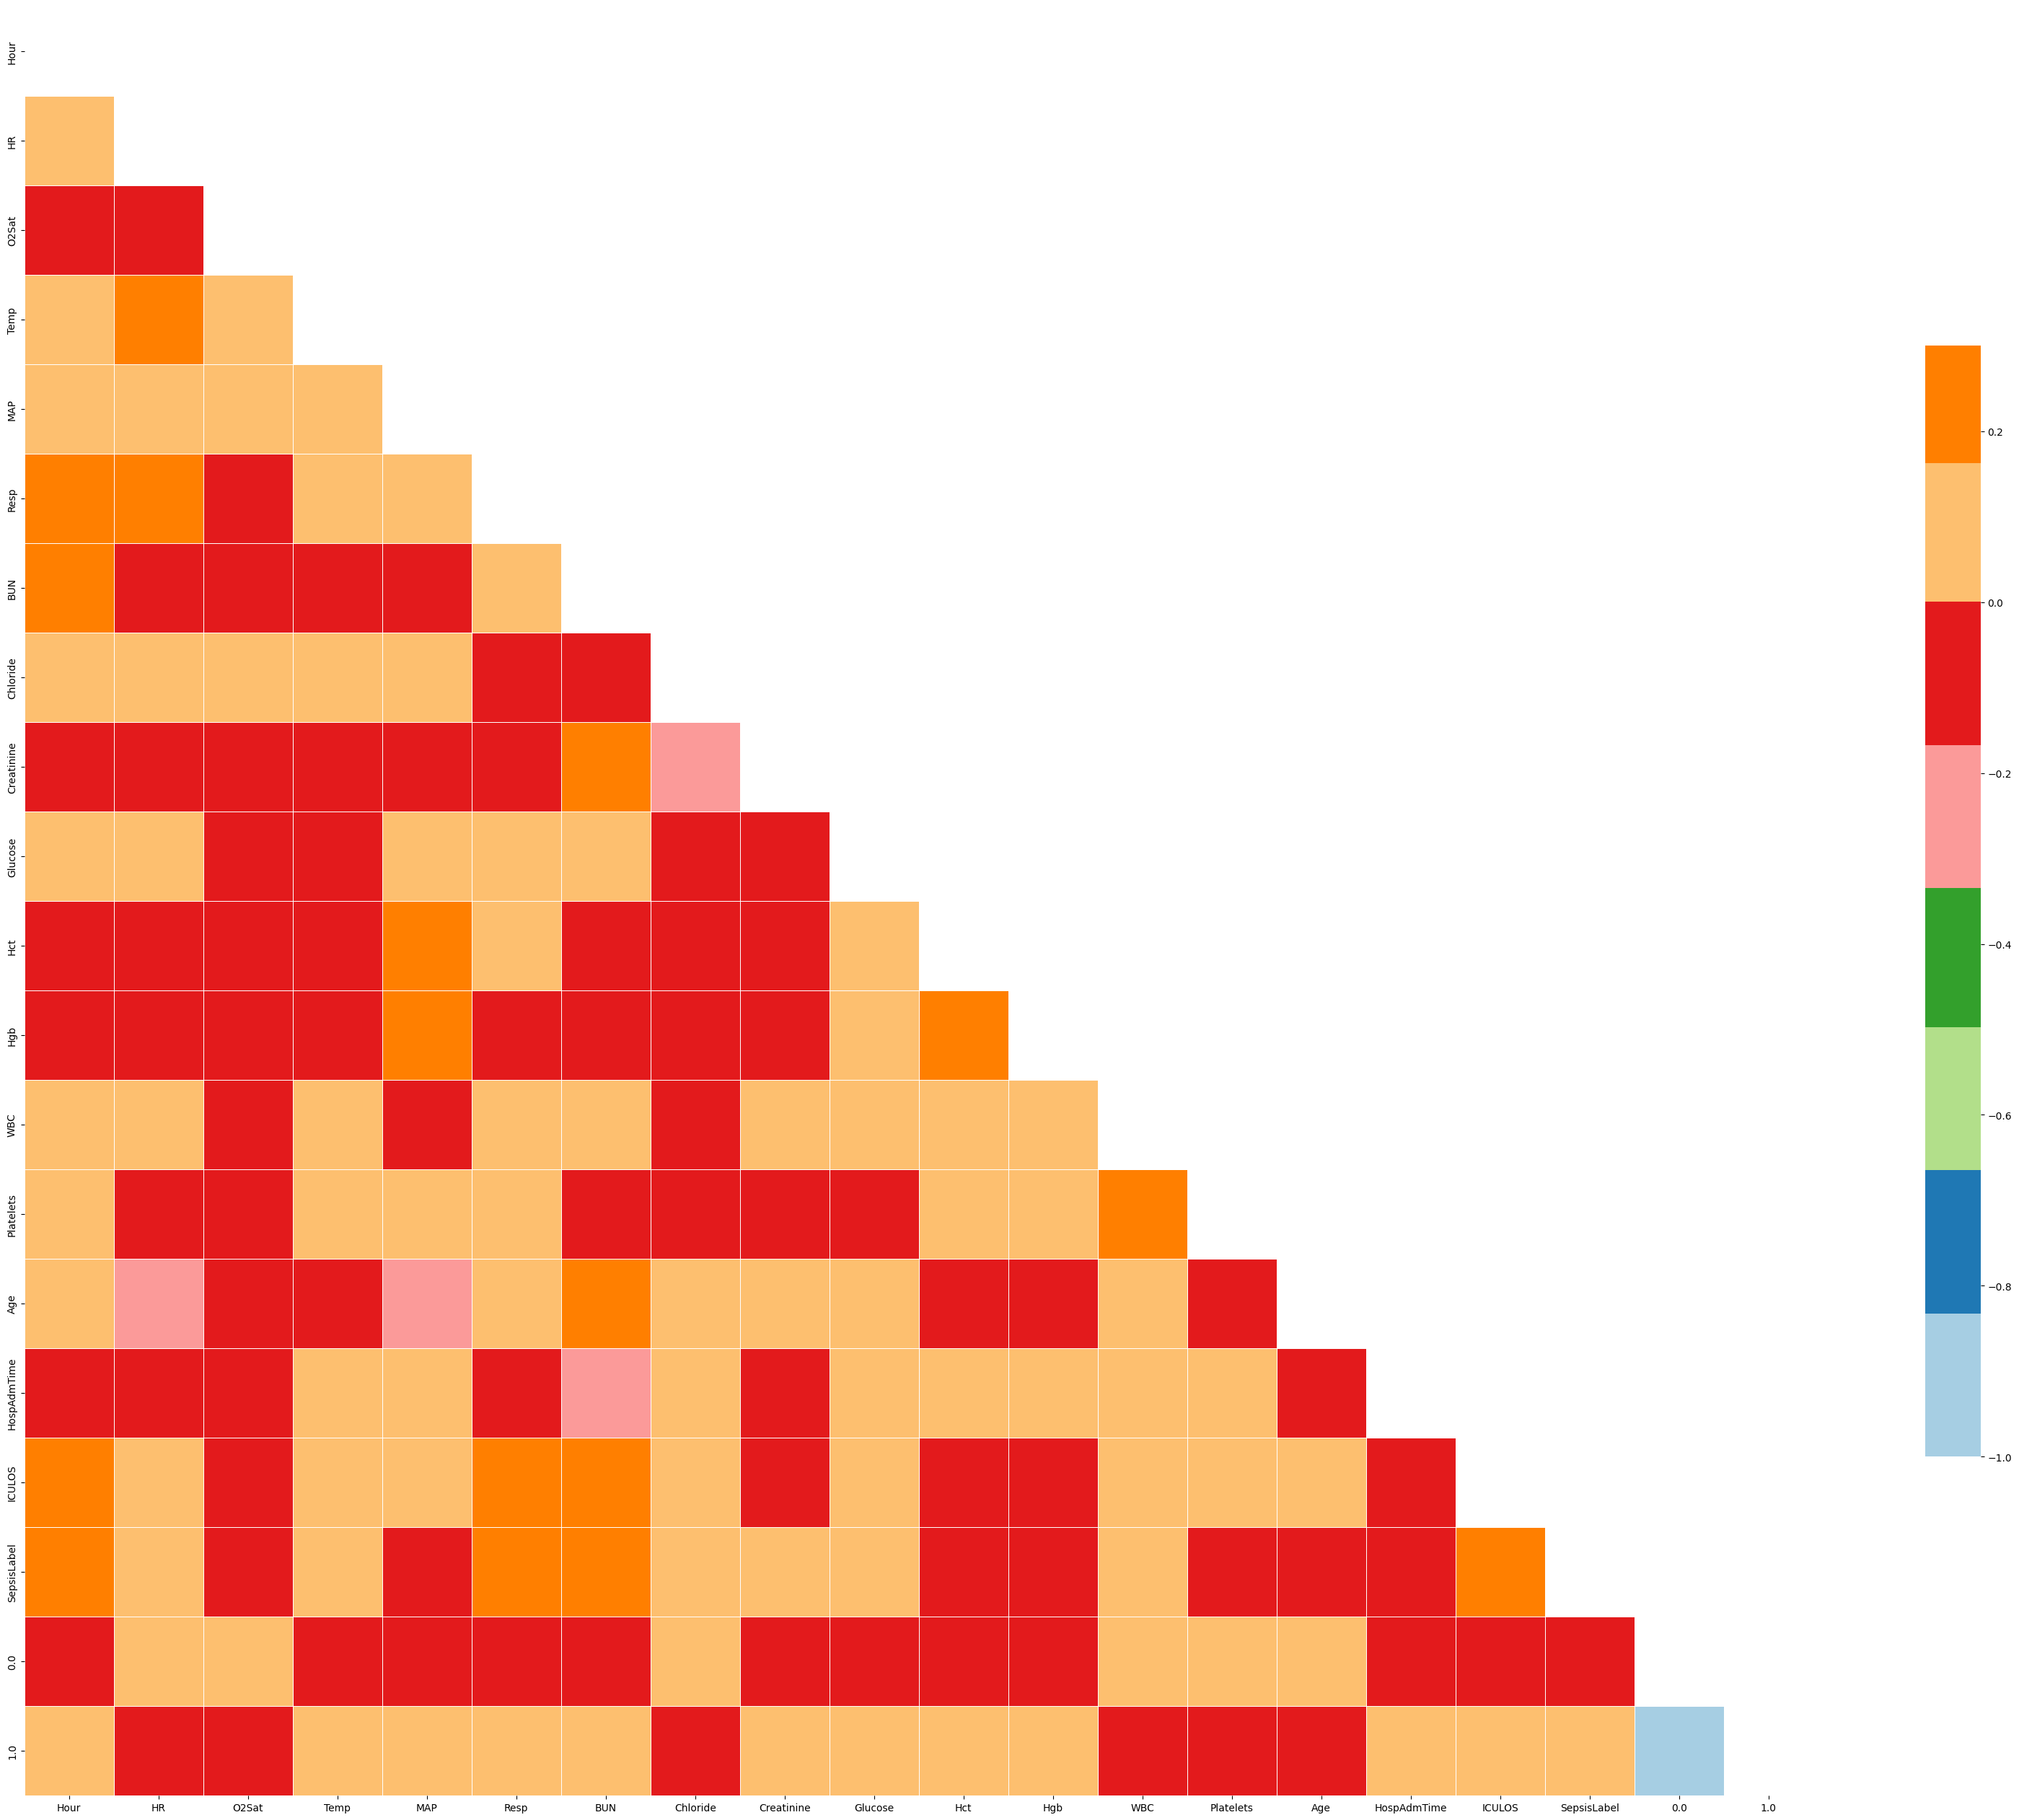

In [ ]:
corr_matrix(df_train_impute)

## Randomforest

In [ ]:
# train test split for the imputed output
# Separating features (X) and target label (y) for modeling
X = df_train_impute.drop('SepsisLabel', axis=1)
y = df_train_impute['SepsisLabel']
# Splitting the balanced data into training and validation sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# random forest classifier
# random forest classifier was tested on different hyper parameters and it gave the best results with number of estimators as 300
# Initializing Random Forest Classifier with 300 decision trees based on previous hyperparameter testing
# model = RandomForestClassifier(n_estimators=100, random_state=0)
# model = RandomForestClassifier(n_estimators=200, random_state=0)
model = RandomForestClassifier(n_estimators=300, random_state=0)

# Reset index and convert column names to strings
# Resetting the index and setting 'Patient_ID' as the new index so it is not treated as a predictive feature
X_train = X_train.reset_index().set_index('Patient_ID')
X_test = X_test.reset_index().set_index('Patient_ID')

# Ensuring all column names are string types to prevent errors during model fitting
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)


model.fit(X_train, y_train) # Training the Random Forest model on the training data
rcf_predictions = model.predict(X_test) # Generating predictions using the validation set

Accuracy: 0.9701897018970189
Precision: 0.9326625386996904
Recall: 0.9812703583061889
F1 Score: 0.9563492063492063
AUC-ROC: 0.9729666170084966
Mean Absolute Error: 0.02981029810298103
Root Mean Squared Error: 0.17265659009427073


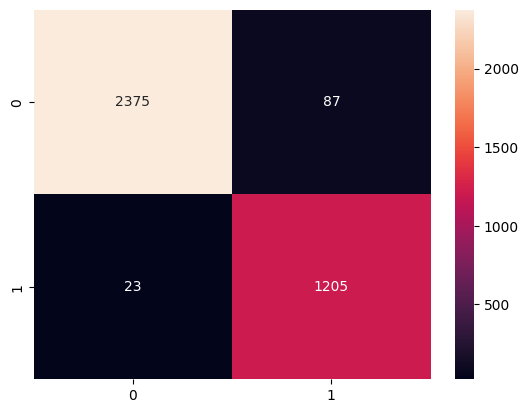

In [ ]:
evaluate_model(y_test,rcf_predictions) # Evaluating the Random Forest model's performance

Accuracy: 0.759349593495935
Precision: 0.7941176470588235
Recall: 0.3737785016286645
F1 Score: 0.5083056478405316
AUC-ROC: 0.6627219071912616
Mean Absolute Error: 0.24065040650406505
Root Mean Squared Error: 0.4905613177820537


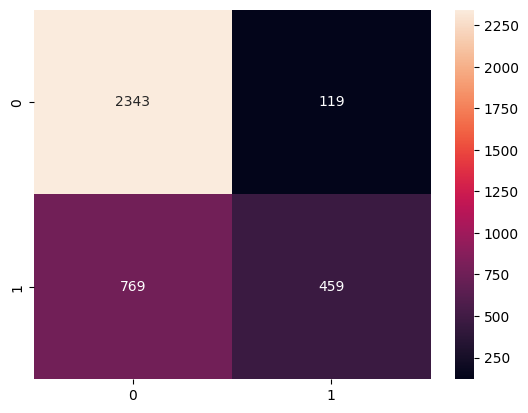

In [ ]:
# Naive Bayes Classifier
# NBC performed worse than random forest on each and every aspect of the evaluation metrics
# Initializing Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)# Training the Naive Bayes mode
nbc_predictions = model.predict(X_test)# Generating predictions
evaluate_model(y_test,nbc_predictions)# Evaluating Naive Bayes performance (expected to be worse than Random Forest)

Accuracy: 0.8344173441734417
Precision: 0.6941472624292008
Recall: 0.8982084690553745
F1 Score: 0.7831025914093007
AUC-ROC: 0.8504039908233818
Mean Absolute Error: 0.16558265582655826
Root Mean Squared Error: 0.4069184879389953


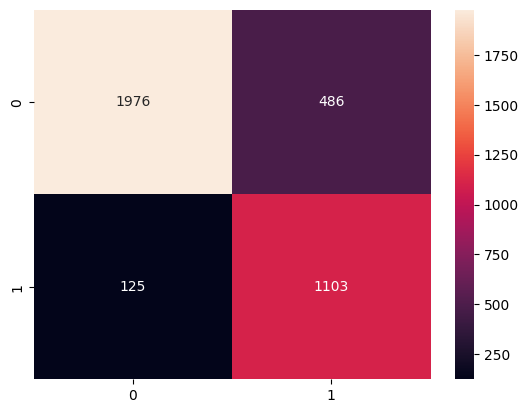

In [ ]:
# KNN Classifier
# KNN was tested on different values of k

from sklearn.neighbors import KNeighborsClassifier# Initializing K-Nearest Neighbors Classifier with 10 neighbors
# model = KNeighborsClassifier(n_neighbors=8)
# model = KNeighborsClassifier(n_neighbors=5)
model = KNeighborsClassifier(n_neighbors=10)
model.fit(X_train, y_train)# Training the KNN model
knn_predictions = model.predict(X_test)# Generating predictions
evaluate_model(y_test,knn_predictions)# Evaluating KNN performance

Accuracy: 0.7506775067750677
Precision: 0.7759856630824373
Recall: 0.3526058631921824
F1 Score: 0.48488241881298993
AUC-ROC: 0.6509170664458069
Mean Absolute Error: 0.24932249322493225
Root Mean Squared Error: 0.49932203358647437


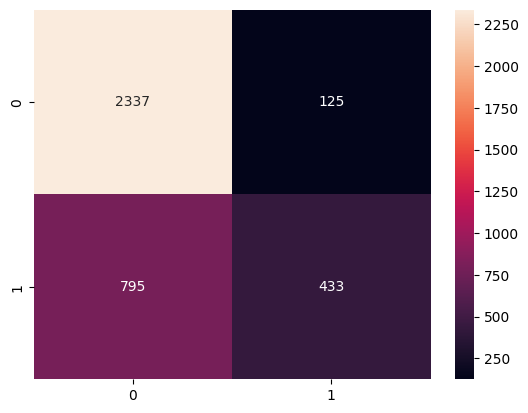

In [ ]:
# Logistic Regression
# Initializing Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)# Training the Logistic Regression model
lr_predictions = model.predict(X_test)# Generating predictions
evaluate_model(y_test,lr_predictions)# Evaluating Logistic Regression performance

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [08:16:25] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "silent" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9230352303523035
Precision: 0.8868852459016393
Recall: 0.8811074918566775
F1 Score: 0.8839869281045751
AUC-ROC: 0.9125277508024249
Mean Absolute Error: 0.07696476964769648
Root Mean Squared Error: 0.2774252505589505


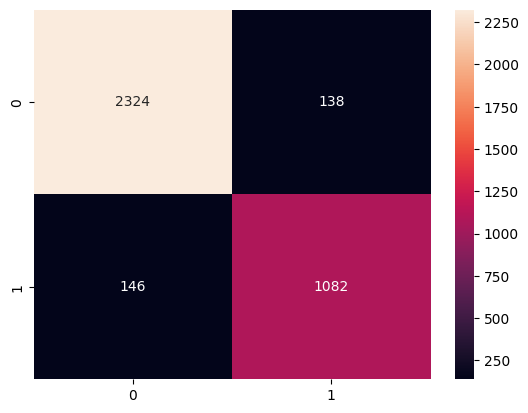

In [ ]:
# XGBoost
# XGBoost was run for different combinations of hyperparameters, but overall random forest classifier performed the best in terms of F1 score and other metrics
# Importing XGBoost library
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)# Converting pandas dataframes into DMatrix objects, which is the internal optimized data structure for XGBoost
dtest = xgb.DMatrix(X_test, label=y_test)
param = { # Defining hyperparameters for the XGBoost model
    'max_depth': 5,  # the maximum depth of each tree
    'eta': 0.3,  # The learning rate or step size for each iteration
    'silent': 1,  # Setting logging mode to quiet (no output during training)
    'objective': 'binary:logistic'}  # error evaluation for binary classification # Using logistic regression for binary classification to output probabilities
num_round = 100 # Number of boosting rounds (trees) to build
bst = xgb.train(param, dtrain, num_round) # Training the XGBoost model
xgb_predictions = bst.predict(dtest) # Predicting probabilities on the validation set
prediction = [] # Converting probabilities into binary class labels (threshold = 0.5)
for i in xgb_predictions:
  if i<0.5:
    prediction.append(0)
  else:
    prediction.append(1)
evaluate_model(y_test,prediction) # Evaluating the XGBoost model's performance

# Testing on the data of the other hospital

/tmp/ipykernel_12/696764516.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = grouped_by_patient.apply(lambda x: x.bfill().ffill())
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Accuracy: 0.9319994719067148
Precision: 0.10445157689087357
Recall: 0.3233959818535321
F1 Score: 0.15790306418437847
AUC-ROC: 0.6338173941712117
Mean Absolute Error: 0.06800052809328512
Root Mean Squared Error: 0.26076910877879134


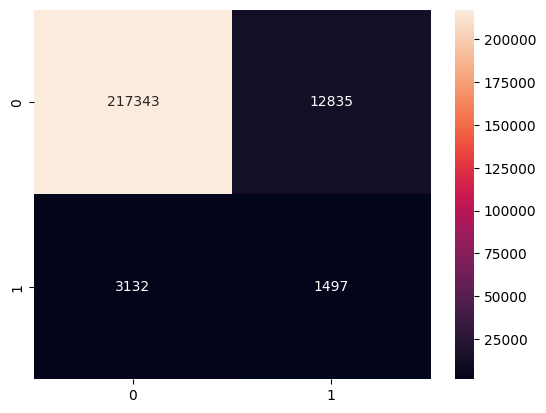

In [ ]:
# testing on the other hospital data
# Preprocessing the external data from the second hospital using the previously defined function
df = get_data_ready(df_test)
X = df.drop('SepsisLabel', axis=1)# Separating features (X) and label (y) for the external testing set
y = df['SepsisLabel']

# Apply the same index resetting and setting as done for training data
# Applying the same index manipulation as done for the training data to align data structures
X = X.reset_index().set_index('Patient_ID')
X.columns = X.columns.astype(str) # Ensure column names are strings

rcf_predictions = model.predict(X) # Using the previously trained model to predict outcomes on the completely unseen data from Hospital 2
evaluate_model(y,rcf_predictions) # Evaluating the model's true generalization ability on the external hospital dataset

In this notebook several models were built to predict the onset of sepsis 6 hours before. After deep analysis several features were dropped and the remaining were imputed. Then the remaining features were applied with gaussian transformation and then normalized, so that a sngle feature won't start dominating the output. After all this exploration and feature engineering, several classifier models were run, in which Random Forest Classifier gave the best results.